# Application du Machine Learning en Cybersécurité (ML for Cybersecurity)

### Détection d'intrusions : Utilisation d'algorithmes de Machine Learning pour détecter des activités suspicieuses ou des intrusions dans les réseaux.

## Étape 1 – Chargement initial du dataset NSL-KDD

### Installation des bibliothèques nécessaires

In [50]:
!pip install imbalanced-learn


   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]


In [1]:
# Install main libraries
!pip install numpy pandas matplotlib seaborn

# Install scikit-learn (includes preprocessing, model selection, metrics, and models)
!pip install scikit-learn

# Install XGBoost
!pip install xgboost

# For Google Colab integration (this will be automatically available in Colab)
# No need to install, but if you want it locally for some reason:
!pip install google-colab

You should consider upgrading via the 'C:\Users\rsica\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


You should consider upgrading via the 'C:\Users\rsica\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


You should consider upgrading via the 'C:\Users\rsica\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


You should consider upgrading via the 'C:\Users\rsica\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.
ERROR: Could not find a version that satisfies the requirement google-colab (from versions: none)
ERROR: No matching distribution found for google-colab
You should consider upgrading via the 'C:\Users\rsica\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


### Importation des bibliothèques

In [116]:
# Bibliothèques pour la manipulation des données
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Bibliothèques pour le préprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Bibliothèques pour les modèles de classification
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

import os
import tensorflow as tf

import matplotlib.pyplot as plt
import numpy as np


# Bibliothèques pour le deep learning (autoencodeur et réseau de neurones)
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, GaussianNoise
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

# Bibliothèques pour la gestion du déséquilibre des classes
from imblearn.over_sampling import SVMSMOTE

# Bibliothèques pour l'évaluation des modèles
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                           f1_score, confusion_matrix, classification_report)

# Configuration pour les graphiques
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

# Suppression des warnings
import warnings
warnings.filterwarnings('ignore')

print("✅ Toutes les bibliothèques ont été importées avec succès !")

✅ Toutes les bibliothèques ont été importées avec succès !


## GOOGLE-COLAB

In [2]:
'''# Montage de Google Drive (nécessaire uniquement sur Colab)
from google.colab import drive
drive.mount('/content/drive')

# Importation des bibliothèques système
import os

# Définition du chemin vers le dossier contenant les données
folder_path = '/content/drive/MyDrive/Colab Notebooks/nslkdd'

# Affichage des fichiers présents dans ce dossier
print("Fichiers disponibles dans le dossier :")
print(os.listdir(folder_path))

# Définition du chemin complet vers le fichier de données
file_path = '/content/drive/MyDrive/Colab Notebooks/nslkdd/'

# Chargement du fichier CSV sans en-tête
data_train = pd.read_csv(file_path + "KDDTrain+.txt", header=None)

# Affichage des 5 premières lignes du DataFrame pour vérification
print("\nAperçu des premières lignes du dataset :")
data_train.head()'''

'# Montage de Google Drive (nécessaire uniquement sur Colab)\nfrom google.colab import drive\ndrive.mount(\'/content/drive\')\n\n# Importation des bibliothèques système\nimport os\n\n# Définition du chemin vers le dossier contenant les données\nfolder_path = \'/content/drive/MyDrive/Colab Notebooks/nslkdd\'\n\n# Affichage des fichiers présents dans ce dossier\nprint("Fichiers disponibles dans le dossier :")\nprint(os.listdir(folder_path))\n\n# Définition du chemin complet vers le fichier de données\nfile_path = \'/content/drive/MyDrive/Colab Notebooks/nslkdd/\'\n\n# Chargement du fichier CSV sans en-tête\ndata_train = pd.read_csv(file_path + "KDDTrain+.txt", header=None)\n\n# Affichage des 5 premières lignes du DataFrame pour vérification\nprint("\nAperçu des premières lignes du dataset :")\ndata_train.head()'

## Chargement du dataset NSL-KDD

### Définition des noms des colonnes selon la documentation NSL-KDD

In [3]:
noms_colonnes = [
    'duree', 'type_protocole', 'service', 'flag', 'nb_octets_src', 'nb_octets_dst',
    'land', 'fragments_incorrects', 'urgent', 'hot', 'nb_connexions_echouees',
    'logged_in', 'nb_compromis', 'root_shell', 'su_tentative', 'nb_acces_root',
    'nb_acces_fichier', 'nb_shells', 'nb_acces_outbound', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
    'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
    'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'classe', 'difficulte'
]

### Chargement des données

In [4]:
print("Chargement des données NSL-KDD...")
donnees_entrainement = pd.read_csv('./datasets/nslkdd/KDDTrain+.txt', 
                                  names=noms_colonnes, header=None)
donnees_test = pd.read_csv('./datasets/nslkdd/KDDTest+.txt', 
                          names=noms_colonnes, header=None)
print("Données chargées avec succès !")

Chargement des données NSL-KDD...
Données chargées avec succès !


### Suppression de la colonne 'difficulte' (non utilisée pour la classification)

In [5]:
donnees_entrainement = donnees_entrainement.drop('difficulte', axis=1)
donnees_test = donnees_test.drop('difficulte', axis=1)

### Identification des colonnes catégorielles et numériques

In [6]:
colonnes_categorielles = ['type_protocole', 'service', 'flag', 'classe']
colonnes_numeriques = [col for col in donnees_entrainement.columns if col not in colonnes_categorielles]


### AFFICHAGE DES INFORMATIONS GÉNÉRALES SUR LE DATASET NSL-KDD

#### Résumé des données

In [7]:
resume_donnees = pd.DataFrame({
    'Dataset': ['Entraînement', 'Test'],
    'Nombre_echantillons': [len(donnees_entrainement), len(donnees_test)],
    'Nombre_caracteristiques': [len(donnees_entrainement.columns)-1, len(donnees_test.columns)-1],
    'Valeurs_manquantes': [donnees_entrainement.isnull().sum().sum(), donnees_test.isnull().sum().sum()]
})

display(resume_donnees)

print(f"\n📋 TYPES DE CARACTÉRISTIQUES:")
print(f"   • Colonnes catégorielles: {len(colonnes_categorielles)}")
print(f"   • Colonnes numériques: {len(colonnes_numeriques)}")

,Dataset,Nombre_echantillons,Nombre_caracteristiques,Valeurs_manquantes
0,Entraînement,125973,40,0
1,Test,22544,40,0



📋 TYPES DE CARACTÉRISTIQUES:
   • Colonnes catégorielles: 4
   • Colonnes numériques: 37


#### Aperçu des données d'entrainement 

In [8]:
display(donnees_entrainement.head())

,duree,type_protocole,service,flag,nb_octets_src,nb_octets_dst,land,fragments_incorrects,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,classe
0,tcp,ftp_data,SF,491,0,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
0,udp,other,SF,146,0,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
0,tcp,private,S0,0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune
0,tcp,http,SF,232,8153,0,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
0,tcp,http,SF,199,420,0,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


## ANALYSE DES DISTRIBUTIONS PRINCIPALES

### Analyse des protocoles

In [9]:
protocoles_stats = donnees_entrainement['type_protocole'].value_counts()

### Analyse des services principaux (top 8 + autres)

In [10]:
services_stats = donnees_entrainement['service'].value_counts()
services_top8 = services_stats.head(8)
services_autres = services_stats.tail(len(services_stats) - 8).sum()
services_finaux = pd.concat([services_top8, pd.Series({'autres': services_autres})])

### Analyse des classes d'attaques

In [11]:
classes_binaires = donnees_entrainement['classe'].apply(lambda x: 'Normal' if x == 'normal' else 'Attaque')
classes_bin_stats = classes_binaires.value_counts()

### Types d'attaques spécifiques

In [12]:
attaques_seulement = donnees_entrainement[donnees_entrainement['classe'] != 'normal']
attaques_stats = attaques_seulement['classe'].value_counts().head(8)

## VISUALISATIONS

### Afficher uniquement les 10 premiers protocoles

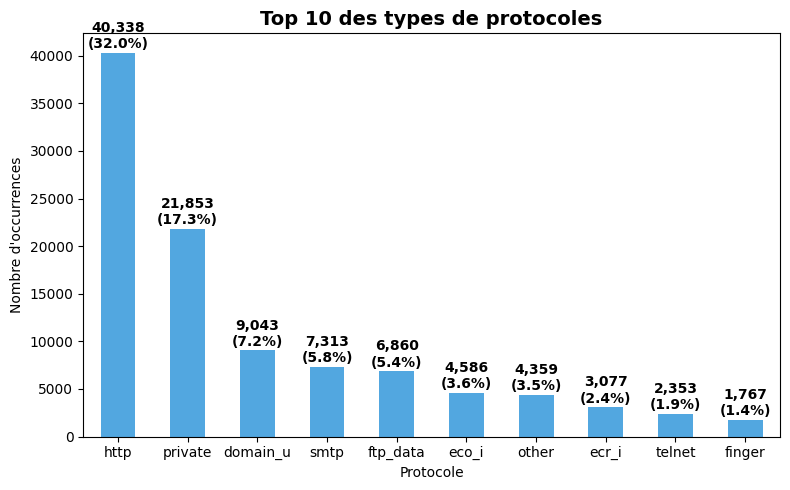

In [13]:
protocoles_top10 = protocoles_stats.head(10)

plt.figure(figsize=(8, 5))
protocoles_top10.plot(kind='bar', color='#3498db', alpha=0.85)

plt.title('Top 10 des types de protocoles', fontweight='bold', fontsize=14)
plt.xlabel('Protocole')
plt.ylabel('Nombre d\'occurrences')
plt.xticks(rotation=0)

for i, (protocole, count) in enumerate(protocoles_top10.items()):
    pourcentage = (count / len(donnees_entrainement)) * 100
    plt.text(i, count + 500, f'{count:,}\n({pourcentage:.1f}%)', 
             ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()


## 2. Répartition des services principaux (Top 8 + "autres")

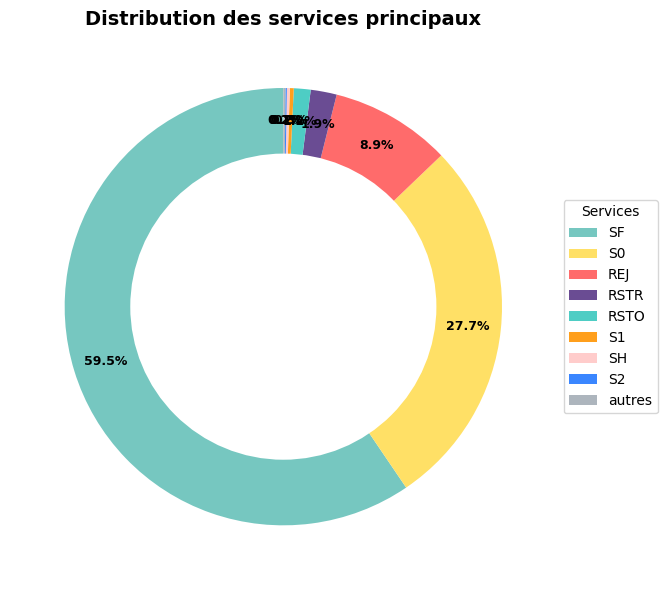

In [14]:

# Couleurs personnalisées (contrastes plus lisibles)
colors_services = ['#76c7c0', '#ffe066', '#ff6b6b', '#6a4c93', '#4ecdc4', '#ff9f1c', '#ffcccb', '#3a86ff', '#adb5bd']

# Création du diagramme circulaire en anneau
plt.figure(figsize=(8, 6))
wedges, texts, autotexts = plt.pie(
    services_finaux.values,
    labels=None,  # on masque les labels ici
    autopct='%1.1f%%',
    colors=colors_services,
    startangle=90,
    pctdistance=0.85
)

# Cercle intérieur pour créer l’effet "donut"
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
plt.gca().add_artist(centre_circle)

# Légende externe claire
plt.legend(
    wedges,
    services_finaux.index,
    title="Services",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=10
)

# Ajustement texte à l’intérieur
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(9)

plt.title('Distribution des services principaux', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()


### 3. Répartition Normal vs Attaques

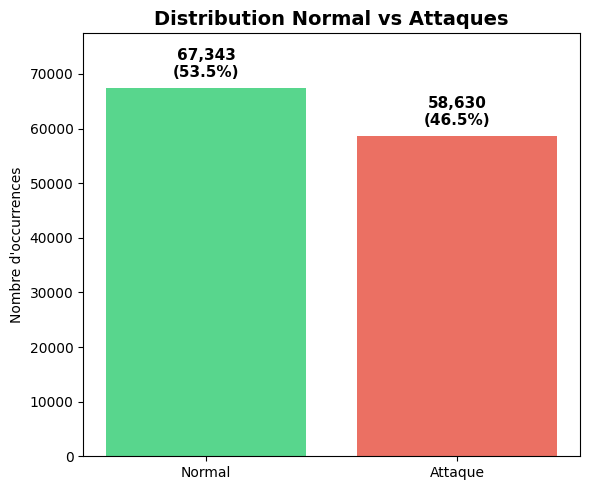

In [15]:
plt.figure(figsize=(6, 5))
bars = plt.bar(classes_bin_stats.index, classes_bin_stats.values, 
               color=['#2ecc71', '#e74c3c'], alpha=0.8)

plt.title('Distribution Normal vs Attaques', fontweight='bold', fontsize=14)
plt.ylabel('Nombre d\'occurrences')

# Détermination de la limite supérieure avec un facteur de sécurité
max_count = classes_bin_stats.max()
plt.ylim(0, max_count * 1.15)  # Ajout de 15% de marge en haut

# Texte repositionné un peu plus bas pour éviter le chevauchement
for i, (classe, count) in enumerate(classes_bin_stats.items()):
    pourcentage = (count / len(donnees_entrainement)) * 100
    plt.text(i, count + max_count * 0.03,  # espacement de 3% sous la limite
             f'{count:,}\n({pourcentage:.1f}%)',
             ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()


###  4. Types d'attaques principales (Top 8)

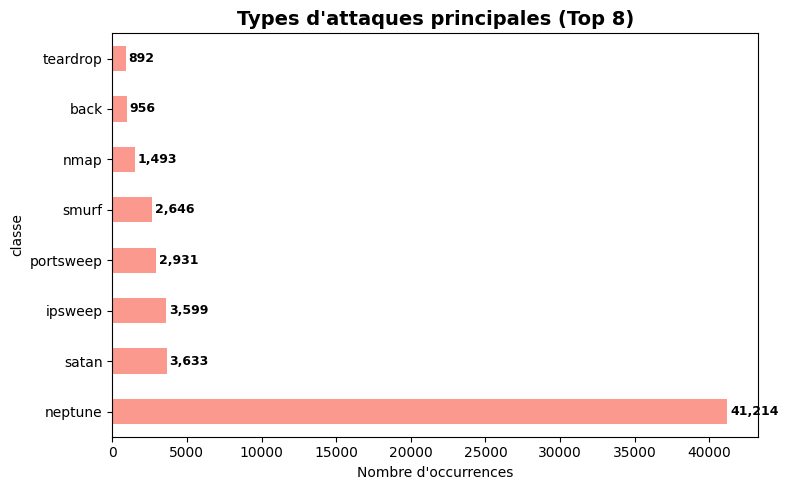

In [16]:
plt.figure(figsize=(8, 5))
attaques_stats.plot(kind='barh', color='salmon', alpha=0.8)

plt.title('Types d\'attaques principales (Top 8)', fontweight='bold', fontsize=14)
plt.xlabel('Nombre d\'occurrences')

for i, count in enumerate(attaques_stats.values):
    plt.text(count + 200, i, f'{count:,}', va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()


### RÉSUMÉ STATISTIQUE

### Protocoles

In [17]:
for protocole, count in protocoles_stats.items():
    pourcentage = (count / len(donnees_entrainement)) * 100
    print(f"   • {protocole}: {count:,} ({pourcentage:.1f}%)")

   • http: 40,338 (32.0%)
   • private: 21,853 (17.3%)
   • domain_u: 9,043 (7.2%)
   • smtp: 7,313 (5.8%)
   • ftp_data: 6,860 (5.4%)
   • eco_i: 4,586 (3.6%)
   • other: 4,359 (3.5%)
   • ecr_i: 3,077 (2.4%)
   • telnet: 2,353 (1.9%)
   • finger: 1,767 (1.4%)
   • ftp: 1,754 (1.4%)
   • auth: 955 (0.8%)
   • Z39_50: 862 (0.7%)
   • uucp: 780 (0.6%)
   • courier: 734 (0.6%)
   • bgp: 710 (0.6%)
   • whois: 693 (0.6%)
   • uucp_path: 689 (0.5%)
   • iso_tsap: 687 (0.5%)
   • time: 654 (0.5%)
   • imap4: 647 (0.5%)
   • nnsp: 630 (0.5%)
   • vmnet: 617 (0.5%)
   • urp_i: 602 (0.5%)
   • domain: 569 (0.5%)
   • ctf: 563 (0.4%)
   • csnet_ns: 545 (0.4%)
   • supdup: 544 (0.4%)
   • discard: 538 (0.4%)
   • http_443: 530 (0.4%)
   • daytime: 521 (0.4%)
   • gopher: 518 (0.4%)
   • efs: 485 (0.4%)
   • systat: 477 (0.4%)
   • link: 475 (0.4%)
   • exec: 474 (0.4%)
   • hostnames: 460 (0.4%)
   • name: 451 (0.4%)
   • mtp: 439 (0.3%)
   • echo: 434 (0.3%)
   • klogin: 433 (0.3%)
   • login: 

#### Services principaux:

In [18]:
for service, count in services_top8.head(5).items():
    pourcentage = (count / len(donnees_entrainement)) * 100
    print(f"   • {service}: {count:,} ({pourcentage:.1f}%)")

   • SF: 74,945 (59.5%)
   • S0: 34,851 (27.7%)
   • REJ: 11,233 (8.9%)
   • RSTR: 2,421 (1.9%)
   • RSTO: 1,562 (1.2%)


#### Répartition des classes:

In [19]:
for classe, count in classes_bin_stats.items():
    pourcentage = (count / len(donnees_entrainement)) * 100
    print(f"   • {classe}: {count:,} ({pourcentage:.1f}%)")

   • Normal: 67,343 (53.5%)
   • Attaque: 58,630 (46.5%)


#### Types d'attaques les plus fréquents

In [20]:
for attaque, count in attaques_stats.head(5).items():
    pourcentage = (count / len(attaques_seulement)) * 100
    print(f"   • {attaque}: {count:,} ({pourcentage:.1f}%)")

   • neptune: 41,214 (70.3%)
   • satan: 3,633 (6.2%)
   • ipsweep: 3,599 (6.1%)
   • portsweep: 2,931 (5.0%)
   • smurf: 2,646 (4.5%)


## ÉTAPE 1: ENCODAGE DES VARIABLES CATÉGORIELLES

### Création de copies des datasets

In [21]:
donnees_train = donnees_entrainement.copy()
donnees_test_final = donnees_test.copy()

### Identification des colonnes catégorielles (qui contiennent du texte)

In [22]:
colonnes_categorielles = ['type_protocole', 'service', 'flag']

print(f"Variables à encoder: {colonnes_categorielles}")

Variables à encoder: ['type_protocole', 'service', 'flag']


### Dictionnaire pour stocker les encodeurs

In [23]:
encodeurs = {}

### Encodage de chaque variable catégorielle

In [24]:
for colonne in colonnes_categorielles:
    print(f"\n   • Encodage de '{colonne}'...")
    
    # Créer un encodeur pour cette colonne
    encodeur = LabelEncoder()
    
    # Combiner les valeurs des deux datasets pour éviter les erreurs
    valeurs_train = donnees_train[colonne].astype(str)
    valeurs_test = donnees_test_final[colonne].astype(str)
    toutes_valeurs = pd.concat([valeurs_train, valeurs_test]).unique()
    
    # Entraîner l'encodeur sur toutes les valeurs
    encodeur.fit(toutes_valeurs)
    
    # Appliquer l'encodage
    donnees_train[colonne] = encodeur.transform(valeurs_train)
    donnees_test_final[colonne] = encodeur.transform(valeurs_test)
    
    # Sauvegarder l'encodeur
    encodeurs[colonne] = encodeur
    
    print(f"      → {len(toutes_valeurs)} valeurs uniques encodées")
    print(f"      → Exemples: {dict(list(zip(toutes_valeurs[:3], range(3))))} ...")


   • Encodage de 'type_protocole'...
      → 70 valeurs uniques encodées
      → Exemples: {'ftp_data': 0, 'other': 1, 'private': 2} ...

   • Encodage de 'service'...
      → 11 valeurs uniques encodées
      → Exemples: {'SF': 0, 'S0': 1, 'REJ': 2} ...

   • Encodage de 'flag'...
      → 3601 valeurs uniques encodées
      → Exemples: {'491': 0, '146': 1, '0': 2} ...


### Vérification que l'encodage a fonctionné

In [25]:
print(f"\n🔍 Vérification:")
for colonne in colonnes_categorielles:
    print(f"   • {colonne}: min={donnees_train[colonne].min()}, max={donnees_train[colonne].max()}")

print(f"\n📊 Aperçu des données encodées:")
display(donnees_train[colonnes_categorielles].head())


🔍 Vérification:
   • type_protocole: min=0, max=69
   • service: min=0, max=10
   • flag: min=0, max=3600

📊 Aperçu des données encodées:


,type_protocole,service,flag
0,20,9,2764
0,44,9,774
0,49,5,0
0,24,9,1684
0,24,9,1362


## ÉTAPE 2: PRÉPARATION DES LABELS DE CLASSIFICATION

### CLASSIFICATION BINAIRE: Normal vs Attaque

#### Créer les labels binaires: 0 = Normal, 1 = Attaque

In [26]:
y_train_binaire = (donnees_train['classe'] != 'normal').astype(int)
y_test_binaire = (donnees_test_final['classe'] != 'normal').astype(int)

#### Statistiques

In [27]:
nb_normal_train = (y_train_binaire == 0).sum()
nb_attaque_train = (y_train_binaire == 1).sum()
nb_normal_test = (y_test_binaire == 0).sum()
nb_attaque_test = (y_test_binaire == 1).sum()

print(f"   • Entraînement:")
print(f"      - Normal (0): {nb_normal_train:,} échantillons ({nb_normal_train/len(y_train_binaire)*100:.1f}%)")
print(f"      - Attaque (1): {nb_attaque_train:,} échantillons ({nb_attaque_train/len(y_train_binaire)*100:.1f}%)")

print(f"   • Test:")
print(f"      - Normal (0): {nb_normal_test:,} échantillons ({nb_normal_test/len(y_test_binaire)*100:.1f}%)")
print(f"      - Attaque (1): {nb_attaque_test:,} échantillons ({nb_attaque_test/len(y_test_binaire)*100:.1f}%)")


   • Entraînement:
      - Normal (0): 67,343 échantillons (53.5%)
      - Attaque (1): 58,630 échantillons (46.5%)
   • Test:
      - Normal (0): 9,711 échantillons (43.1%)
      - Attaque (1): 12,833 échantillons (56.9%)


### CLASSIFICATION MULTI-CLASSES: 4 catégories d'attaques

#### Fonction pour catégoriser les attaques selon les 4 types principaux

In [28]:
def categoriser_attaque(classe):
    """Catégorise les attaques selon les 4 types principaux"""
    if classe == 'normal':
        return 'Normal'
    
    # DoS attacks (Denial of Service)
    dos_attacks = ['neptune', 'smurf', 'pod', 'teardrop', 'land', 'back', 
                   'apache2', 'mailbomb', 'processtable', 'udpstorm']
    
    # Probe attacks (scanning/probing)
    probe_attacks = ['satan', 'portsweep', 'nmap', 'ipsweep', 'saint', 'mscan']
    
    # R2L attacks (Remote to Local)
    r2l_attacks = ['warezclient', 'imap', 'ftp_write', 'guess_passwd', 'spy', 
                   'phf', 'multihop', 'warezmaster', 'worm', 'httptunnel', 
                   'sendmail', 'snmpgetattack', 'named', 'xlock', 'xsnoop', 'snmpguess']
    
    # U2R attacks (User to Root)
    u2r_attacks = ['buffer_overflow', 'loadmodule', 'perl', 'rootkit', 
                   'xterm', 'ps', 'sqlattack']
    
    # Classification
    if classe in dos_attacks:
        return 'DoS'
    elif classe in probe_attacks:
        return 'Probe'
    elif classe in r2l_attacks:
        return 'R2L'
    elif classe in u2r_attacks:
        return 'U2R'
    else:
        # Pour les attaques non reconnues, les classer comme DoS par défaut
        return 'DoS'

#### Application de la catégorisation

In [29]:
categories_train = donnees_train['classe'].apply(categoriser_attaque)
categories_test = donnees_test_final['classe'].apply(categoriser_attaque)

#### Vérification des catégories créées

In [30]:
print(f"   • Catégories trouvées: {sorted(categories_train.unique())}")

   • Catégories trouvées: ['DoS', 'Normal', 'Probe', 'R2L', 'U2R']


#### Encodage des catégories avec un ordre fixe

In [31]:
encodeur_categories = LabelEncoder()
categories_ordre = ['Normal', 'DoS', 'Probe', 'R2L', 'U2R']
encodeur_categories.fit(categories_ordre)

LabelEncoder()

#### Transformation des labels

In [32]:
y_train_multi = encodeur_categories.transform(categories_train)
y_test_multi = encodeur_categories.transform(categories_test)

#### Statistiques détaillées

In [33]:
print(f"\n   • Distribution des catégories:")
for i, categorie in enumerate(encodeur_categories.classes_):
    count_train = (y_train_multi == i).sum()
    count_test = (y_test_multi == i).sum()
    pct_train = count_train / len(y_train_multi) * 100
    pct_test = count_test / len(y_test_multi) * 100
    print(f"      - {categorie} (code {i}):")
    print(f"        Train: {count_train:,} ({pct_train:.1f}%) | Test: {count_test:,} ({pct_test:.1f}%)")



   • Distribution des catégories:
      - DoS (code 0):
        Train: 45,927 (36.5%) | Test: 7,458 (33.1%)
      - Normal (code 1):
        Train: 67,343 (53.5%) | Test: 9,711 (43.1%)
      - Probe (code 2):
        Train: 11,656 (9.3%) | Test: 2,421 (10.7%)
      - R2L (code 3):
        Train: 995 (0.8%) | Test: 2,887 (12.8%)
      - U2R (code 4):
        Train: 52 (0.0%) | Test: 67 (0.3%)


#### RÉSUMÉ DE L'ÉTAPE 2

In [34]:
print(f"\n✅ Préparation des labels terminée!")
print(f"   • Labels binaires créés: {len(np.unique(y_train_binaire))} classes")
print(f"   • Labels multi-classes créés: {len(np.unique(y_train_multi))} classes")

# Sauvegarde de l'encodeur pour référence future
print(f"\n📝 Mapping des catégories sauvegardé:")
mapping_categories = dict(zip(encodeur_categories.classes_, range(len(encodeur_categories.classes_))))
for categorie, code in mapping_categories.items():
    print(f"   • {categorie} → {code}")


✅ Préparation des labels terminée!
   • Labels binaires créés: 2 classes
   • Labels multi-classes créés: 5 classes

📝 Mapping des catégories sauvegardé:
   • DoS → 0
   • Normal → 1
   • Probe → 2
   • R2L → 3
   • U2R → 4


## ÉTAPE 3: PRÉPARATION DES CARACTÉRISTIQUES ET STANDARDISATION

### SÉPARATION DES CARACTÉRISTIQUES (FEATURES)

#### Supprimer la colonne 'classe' pour obtenir les features

In [35]:
X_train = donnees_train.drop('classe', axis=1)
X_test = donnees_test_final.drop('classe', axis=1)

print(f"   • Nombre de caractéristiques: {X_train.shape[1]}")
print(f"   • Échantillons d'entraînement: {X_train.shape[0]:,}")
print(f"   • Échantillons de test: {X_test.shape[0]:,}")


   • Nombre de caractéristiques: 40
   • Échantillons d'entraînement: 125,973
   • Échantillons de test: 22,544


### VÉRIFICATION DES TYPES DE DONNÉES

#### Vérifier les types après encodage

In [36]:
types_donnees = X_train.dtypes.value_counts()
print(f"   • Types présents: {dict(types_donnees)}")

   • Types présents: {dtype('int64'): 21, dtype('float64'): 15, dtype('int32'): 3, dtype('O'): 1}


#### Vérifier s'il reste des colonnes non-numériques

In [37]:
colonnes_non_numeriques = X_train.select_dtypes(include=['object']).columns
if len(colonnes_non_numeriques) > 0:
    print(f"   ⚠️ Colonnes encore non-numériques: {list(colonnes_non_numeriques)}")
    # Conversion forcée si nécessaire
    for col in colonnes_non_numeriques:
        X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
        X_test[col] = pd.to_numeric(X_test[col], errors='coerce')
    print(f"   ✅ Conversion forcée appliquée")

   ⚠️ Colonnes encore non-numériques: ['duree']
   ✅ Conversion forcée appliquée


#### Vérification des valeurs manquantes

In [38]:
valeurs_manquantes_train = X_train.isnull().sum().sum()
valeurs_manquantes_test = X_test.isnull().sum().sum()

print(f"   • Valeurs manquantes - Train: {valeurs_manquantes_train}")
print(f"   • Valeurs manquantes - Test: {valeurs_manquantes_test}")

if valeurs_manquantes_train > 0 or valeurs_manquantes_test > 0:
    X_train = X_train.fillna(0)
    X_test = X_test.fillna(0)
    print(f"   ✅ Valeurs manquantes remplacées par 0")


   • Valeurs manquantes - Train: 125973
   • Valeurs manquantes - Test: 22544
   ✅ Valeurs manquantes remplacées par 0


### STANDARDISATION DES DONNÉES

#### Standardisation des données: Avant standardisation:

In [39]:
print(f"- Moyenne générale: {X_train.mean().mean():.3f}")
print(f"- Écart-type général: {X_train.std().mean():.3f}")
print(f"- Min général: {X_train.min().min():.3f}")
print(f"- Max général: {X_train.max().max():.3f}")

- Moyenne générale: 534.283
- Écart-type général: 100572.748
- Min général: 0.000
- Max général: 1309937401.000


#### Application de la standardisation (Z-score normalization)

In [40]:
standardiseur = StandardScaler()

#### Entraînement sur les données d'entraînement uniquement

In [41]:
X_train_std = standardiseur.fit_transform(X_train)
X_test_std = standardiseur.transform(X_test)

#### Reconversion en DataFrame pour garder les noms des colonnes

In [42]:
X_train_std = pd.DataFrame(X_train_std, columns=X_train.columns, index=X_train.index)
X_test_std = pd.DataFrame(X_test_std, columns=X_test.columns, index=X_test.index)

print(f"\n   • Après standardisation:")
print(f"      - Moyenne générale: {X_train_std.mean().mean():.6f}")
print(f"      - Écart-type général: {X_train_std.std().mean():.6f}")
print(f"      - Min général: {X_train_std.min().min():.3f}")
print(f"      - Max général: {X_train_std.max().max():.3f}")


   • Après standardisation:
      - Moyenne générale: -0.000000
      - Écart-type général: 0.950004
      - Min général: -2.595
      - Max général: 354.925


### APERÇU DES DONNÉES FINALES

#### Aperçu des données standardisées:

In [43]:
display(X_train_std.head())

,duree,type_protocole,service,flag,nb_octets_src,nb_octets_dst,land,fragments_incorrects,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,0.0,-0.686785,0.751111,1.390963,-0.004919,-0.014089,-0.089486,-0.007736,-0.095076,-0.027023,...,-0.324063,-0.818890,-0.782367,-0.280282,0.069972,-0.289103,-0.639532,-0.624871,-0.224532,-0.376387
0,0.0,0.781428,0.751111,-0.313392,-0.004919,-0.014089,-0.089486,-0.007736,-0.095076,-0.027023,...,0.734343,-1.035688,-1.161030,2.736852,2.367737,-0.289103,-0.639532,-0.624871,-0.387635,-0.376387
0,0.0,1.087305,-0.736235,-0.976292,-0.004919,-0.014089,-0.089486,-0.007736,-0.095076,-0.027023,...,0.734343,-0.809857,-0.938287,-0.174417,-0.480197,-0.289103,1.608759,1.618955,-0.387635,-0.376387
0,0.0,-0.442083,0.751111,0.465986,-0.002891,-0.014089,-0.089486,-0.007736,-0.095076,-0.027023,...,-1.533670,1.258754,1.066401,-0.439078,-0.383108,0.066252,-0.572083,-0.602433,-0.387635,-0.345084
0,0.0,-0.442083,0.751111,0.190206,-0.004814,-0.014089,-0.089486,-0.007736,-0.095076,-0.027023,...,0.734343,1.258754,1.066401,-0.439078,-0.480197,-0.289103,-0.639532,-0.624871,-0.387635,-0.376387


#### Statistiques de quelques caractéristiques:

In [44]:
colonnes_exemple = X_train_std.columns[:5]
stats_exemple = X_train_std[colonnes_exemple].describe()
display(stats_exemple)

,duree,type_protocole,service,flag,nb_octets_src
count,125973.0,1.259730e+05,1.259730e+05,1.259730e+05,1.259730e+05
mean,0.0,6.407536e-17,8.387329e-17,-1.139368e-17,7.614590e-19
std,0.0,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00
min,0.0,-1.910296e+00,-2.595417e+00,-9.762916e-01,-4.918644e-03
25%,0.0,-6.867852e-01,-7.362346e-01,-9.762916e-01,-4.918644e-03
50%,0.0,-4.420831e-01,7.511113e-01,-1.823535e-01,-4.918644e-03
75%,0.0,1.087305e+00,7.511113e-01,8.976422e-01,-4.790326e-03
max,0.0,2.310816e+00,1.122948e+00,2.106963e+00,3.257486e+02


### RÉSUMÉ DE L'ÉTAPE 3

In [45]:
print(f"\n✅ Préparation des caractéristiques terminée!")
print(f"   • Caractéristiques séparées: {X_train_std.shape[1]} colonnes")
print(f"   • Données standardisées avec succès")
print(f"   • Prêt pour l'entraînement des modèles")

print(f"\n📋 Résumé des données préparées:")
print(f"   • X_train_std: {X_train_std.shape}")
print(f"   • X_test_std: {X_test_std.shape}")
print(f"   • y_train_binaire: {y_train_binaire.shape}")
print(f"   • y_test_binaire: {y_test_binaire.shape}")
print(f"   • y_train_multi: {y_train_multi.shape}")
print(f"   • y_test_multi: {y_test_multi.shape}")


✅ Préparation des caractéristiques terminée!
   • Caractéristiques séparées: 40 colonnes
   • Données standardisées avec succès
   • Prêt pour l'entraînement des modèles

📋 Résumé des données préparées:
   • X_train_std: (125973, 40)
   • X_test_std: (22544, 40)
   • y_train_binaire: (125973,)
   • y_test_binaire: (22544,)
   • y_train_multi: (125973,)
   • y_test_multi: (22544,)


### CONFIGURATION POUR SUPPRIMER LES WARNINGS TENSORFLOW

In [46]:
import os
import tensorflow as tf

#### Suppression des warnings TensorFlow

In [47]:
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Supprime les messages INFO et WARNING
tf.get_logger().setLevel('ERROR')  # Ne montre que les erreurs

#### Désactivation des warnings de dépréciation

In [48]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

## ÉTAPE 4: CLASSIFICATION BINAIRE (NORMAL VS ATTAQUE)

### ENTRAÎNEMENT DES MODÈLES CLASSIQUES DE CLASSIFICATION

#### Dictionnaire pour stocker les modèles et leurs résultats

In [49]:
modeles_binaires = {}
resultats_binaires = {}

#### Définition des modèles à tester

In [50]:
modeles_config = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Naive Bayes': GaussianNB(),
    'SVM': SVC(random_state=42, probability=True),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'MLP': MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)
}

print(f"   • Modèles à entraîner: {len(modeles_config)}")

   • Modèles à entraîner: 7


#### Entraînement et évaluation de chaque modèle

In [51]:
for nom_modele, modele in modeles_config.items():
    print(f"\n   🔹 Entraînement: {nom_modele}")
    
    # Entraînement
    start_time = pd.Timestamp.now()
    modele.fit(X_train_std, y_train_binaire)
    temps_entrainement = (pd.Timestamp.now() - start_time).total_seconds()
    
    # Prédictions
    y_pred_train = modele.predict(X_train_std)
    y_pred_test = modele.predict(X_test_std)
    
    # Calcul des métriques
    accuracy_train = accuracy_score(y_train_binaire, y_pred_train)
    accuracy_test = accuracy_score(y_test_binaire, y_pred_test)
    precision_test = precision_score(y_test_binaire, y_pred_test)
    recall_test = recall_score(y_test_binaire, y_pred_test)
    f1_test = f1_score(y_test_binaire, y_pred_test)
    
    # Stockage des résultats
    modeles_binaires[nom_modele] = modele
    resultats_binaires[nom_modele] = {
        'accuracy_train': accuracy_train,
        'accuracy_test': accuracy_test,
        'precision': precision_test,
        'recall': recall_test,
        'f1_score': f1_test,
        'temps_entrainement': temps_entrainement
    }
    
    print(f"      ✅ Terminé - Accuracy test: {accuracy_test:.3f} | F1: {f1_test:.3f} | Temps: {temps_entrainement:.1f}s")


   🔹 Entraînement: Decision Tree
      ✅ Terminé - Accuracy test: 0.785 | F1: 0.773 | Temps: 1.0s

   🔹 Entraînement: Random Forest
      ✅ Terminé - Accuracy test: 0.763 | F1: 0.743 | Temps: 10.1s

   🔹 Entraînement: Naive Bayes
      ✅ Terminé - Accuracy test: 0.773 | F1: 0.772 | Temps: 0.1s

   🔹 Entraînement: SVM
      ✅ Terminé - Accuracy test: 0.809 | F1: 0.803 | Temps: 436.0s

   🔹 Entraînement: AdaBoost
      ✅ Terminé - Accuracy test: 0.773 | F1: 0.759 | Temps: 11.9s

   🔹 Entraînement: Gradient Boosting
      ✅ Terminé - Accuracy test: 0.790 | F1: 0.779 | Temps: 23.2s

   🔹 Entraînement: MLP
      ✅ Terminé - Accuracy test: 0.819 | F1: 0.816 | Temps: 179.9s


### Construction de l'autoencodeur pour détection d'anomalies

#### Préparation des données normales uniquement pour l'autoencodeur

In [52]:
X_normal_train = X_train_std[y_train_binaire == 0]
print(f"   • Données normales pour entraînement: {len(X_normal_train):,} échantillons")

   • Données normales pour entraînement: 67,343 échantillons


#### Architecture de l'autoencodeur

In [53]:
nb_features = X_train_std.shape[1]
taille_encodage = 15  # Dimension de l'espace latent réduit

print(f"   • Nombre de caractéristiques d'entrée: {nb_features}")
print(f"   • Taille de l'espace d'encodage: {taille_encodage}")

   • Nombre de caractéristiques d'entrée: 40
   • Taille de l'espace d'encodage: 15


#### Construction du modèle autoencodeur avec la nouvelle API Keras

In [54]:
# Utilisation de tf.keras au lieu de keras directement
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GaussianNoise
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

autoencodeur = Sequential([
    # Couche d'entrée avec bruit gaussien pour régularisation
    GaussianNoise(0.15, input_shape=(nb_features,)),
    
    # Encodeur
    Dense(taille_encodage, activation='selu', name='encodage'),
    Dropout(0.05),
    
    # Décodeur
    Dense(nb_features, activation='selu', name='decodage')
])

#### Compilation du modèle

In [55]:
autoencodeur.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

print(f"   ✅ Architecture construite")
print(f"      - Encodeur: {nb_features} → {taille_encodage}")
print(f"      - Décodeur: {taille_encodage} → {nb_features}")

   ✅ Architecture construite
      - Encodeur: 40 → 15
      - Décodeur: 15 → 40


#### Entraînement de l'autoencodeur

In [56]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True,
    verbose=0
)

#### Entraînement avec suppression de la verbosité

In [57]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    historique = autoencodeur.fit(
        X_normal_train, X_normal_train,  # Autoencodeur: input = output
        epochs=100,
        batch_size=32,
        validation_split=0.15,
        callbacks=[early_stopping],
        verbose=0
    )

print(f"   ✅ Entraînement terminé après {len(historique.history['loss'])} époques")
print(f"      - Perte finale d'entraînement: {historique.history['loss'][-1]:.6f}")
print(f"      - Perte finale de validation: {historique.history['val_loss'][-1]:.6f}")


   ✅ Entraînement terminé après 13 époques
      - Perte finale d'entraînement: 0.139774
      - Perte finale de validation: 0.068785


### ÉVALUATION DE L'AUTOENCODEUR

#### Calcul des erreurs de reconstruction avec suppression de la verbosité

In [58]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    erreurs_train = np.mean(np.square(X_train_std - autoencodeur.predict(X_train_std, verbose=0)), axis=1)
    erreurs_test = np.mean(np.square(X_test_std - autoencodeur.predict(X_test_std, verbose=0)), axis=1)

#### Calcul du seuil basé sur les données normales d'entraînement

In [59]:
erreurs_normales = erreurs_train[y_train_binaire == 0]
seuil_anomalie = np.percentile(erreurs_normales, 95)  # 95e percentile
print(f"   • Seuil de détection d'anomalie: {seuil_anomalie:.6f}")
print(f"   • Erreur moyenne sur données normales: {erreurs_normales.mean():.6f}")

   • Seuil de détection d'anomalie: 0.177216
   • Erreur moyenne sur données normales: 0.113982


#### Prédictions de l'autoencodeur

In [60]:
pred_autoencodeur_train = (erreurs_train > seuil_anomalie).astype(int)
pred_autoencodeur_test = (erreurs_test > seuil_anomalie).astype(int)

#### Métriques de l'autoencodeur

In [61]:
accuracy_ae_test = accuracy_score(y_test_binaire, pred_autoencodeur_test)
precision_ae_test = precision_score(y_test_binaire, pred_autoencodeur_test)
recall_ae_test = recall_score(y_test_binaire, pred_autoencodeur_test)
f1_ae_test = f1_score(y_test_binaire, pred_autoencodeur_test)

#### Ajout des résultats de l'autoencodeur

In [62]:
modeles_binaires['Autoencodeur'] = autoencodeur
resultats_binaires['Autoencodeur'] = {
    'accuracy_test': accuracy_ae_test,
    'precision': precision_ae_test,
    'recall': recall_ae_test,
    'f1_score': f1_ae_test,
    'seuil': seuil_anomalie
}

print(f"   ✅ Évaluation terminée")
print(f"      - Accuracy: {accuracy_ae_test:.3f}")
print(f"      - F1-score: {f1_ae_test:.3f}")

   ✅ Évaluation terminée
      - Accuracy: 0.766
      - F1-score: 0.757


### RÉSULTATS DE LA CLASSIFICATION BINAIRE:

#### Création du tableau comparatif

In [63]:
resultats_df = pd.DataFrame(resultats_binaires).T
resultats_df = resultats_df.round(4)

#### Tri par F1-score décroissant

In [64]:
resultats_df = resultats_df.sort_values('f1_score', ascending=False)

display(resultats_df.style.set_caption("Comparaison des modèles de classification binaire")
        .highlight_max(subset=['accuracy_test', 'f1_score'], color='lightgreen')
        .format({'accuracy_test': '{:.3f}', 'precision': '{:.3f}', 
                'recall': '{:.3f}', 'f1_score': '{:.3f}'}))

,accuracy_train,accuracy_test,precision,recall,f1_score,temps_entrainement,seuil
MLP,0.998400,0.819,0.970,0.704,0.816,179.875200,nan
SVM,0.992900,0.809,0.972,0.685,0.803,435.963700,nan
Gradient Boosting,0.994600,0.790,0.968,0.652,0.779,23.198200,nan
Decision Tree,0.999900,0.785,0.966,0.645,0.773,1.046800,nan
Naive Bayes,0.891100,0.773,0.906,0.672,0.772,0.085400,nan
AdaBoost,0.980600,0.773,0.959,0.628,0.759,11.920700,nan
Autoencodeur,nan,0.766,0.922,0.643,0.757,nan,0.177200
Random Forest,0.999900,0.763,0.968,0.603,0.743,10.114900,nan


#### Identification du meilleur modèle

In [65]:
meilleur_modele_nom = resultats_df.index[0]
meilleur_score = resultats_df.iloc[0]['f1_score']

print(f"\n🏆 Meilleur modèle: {meilleur_modele_nom}")
print(f"   • F1-score: {meilleur_score:.3f}")
print(f"   • Accuracy: {resultats_df.iloc[0]['accuracy_test']:.3f}")

print(f"\n✅ Classification binaire terminée!")


🏆 Meilleur modèle: MLP
   • F1-score: 0.816
   • Accuracy: 0.819

✅ Classification binaire terminée!


## ÉTAPE 5: CLASSIFICATION MULTI-CLASSES AVEC GESTION DU DÉSÉQUILIBRE

### ANALYSE DU DÉSÉQUILIBRE DES CLASSES

#### Compter les échantillons par classe

In [66]:
comptage_classes = pd.Series(y_train_multi).value_counts().sort_index()
noms_classes = encodeur_categories.classes_

print(f"   • Distribution actuelle:")
for i, nom_classe in enumerate(noms_classes):
    count = comptage_classes[i]
    pourcentage = (count / len(y_train_multi)) * 100
    print(f"      - {nom_classe}: {count:,} échantillons ({pourcentage:.1f}%)")

   • Distribution actuelle:
      - DoS: 45,927 échantillons (36.5%)
      - Normal: 67,343 échantillons (53.5%)
      - Probe: 11,656 échantillons (9.3%)
      - R2L: 995 échantillons (0.8%)
      - U2R: 52 échantillons (0.0%)


#### Calcul du ratio de déséquilibre

In [67]:
ratio_desequilibre = comptage_classes.max() / comptage_classes.min()
print(f"\n   • Ratio de déséquilibre: {ratio_desequilibre:.1f}:1")
print(f"   • Classe majoritaire: {noms_classes[comptage_classes.idxmax()]}")
print(f"   • Classe minoritaire: {noms_classes[comptage_classes.idxmin()]}")


   • Ratio de déséquilibre: 1295.1:1
   • Classe majoritaire: Normal
   • Classe minoritaire: U2R


### APPLICATION DE SVM-SMOTE POUR RÉÉQUILIBRER LES DONNÉES

#### Configuration de SVM-SMOTE

In [68]:
smote = SVMSMOTE(random_state=42, k_neighbors=5)

print(f"   • Technique utilisée: SVM-SMOTE")
print(f"   • Données avant SMOTE: {X_train_std.shape[0]:,} échantillons")

   • Technique utilisée: SVM-SMOTE
   • Données avant SMOTE: 125,973 échantillons


#### Application de SMOTE

In [69]:
X_train_equilibre, y_train_equilibre = smote.fit_resample(X_train_std, y_train_multi)

print(f"   • Données après SMOTE: {X_train_equilibre.shape[0]:,} échantillons")
print(f"   • Augmentation: +{X_train_equilibre.shape[0] - X_train_std.shape[0]:,} échantillons")

   • Données après SMOTE: 336,715 échantillons
   • Augmentation: +210,742 échantillons


#### Vérification de l'équilibrage

In [70]:
comptage_equilibre = pd.Series(y_train_equilibre).value_counts().sort_index()
print(f"\n   • Distribution après équilibrage:")
for i, nom_classe in enumerate(noms_classes):
    count_avant = comptage_classes[i]
    count_apres = comptage_equilibre[i]
    augmentation = count_apres - count_avant
    print(f"      - {nom_classe}: {count_avant:,} → {count_apres:,} (+{augmentation:,})")


   • Distribution après équilibrage:
      - DoS: 45,927 → 67,343 (+21,416)
      - Normal: 67,343 → 67,343 (+0)
      - Probe: 11,656 → 67,343 (+55,687)
      - R2L: 995 → 67,343 (+66,348)
      - U2R: 52 → 67,343 (+67,291)


### CONSTRUCTION DU RÉSEAU DE NEURONES PROFOND

#### Construction du réseau de neurones pour classification multi-classes:

In [71]:
nb_classes = len(noms_classes)
nb_features = X_train_equilibre.shape[1]

print(f"   • Nombre de caractéristiques: {nb_features}")
print(f"   • Nombre de classes: {nb_classes}")

   • Nombre de caractéristiques: 40
   • Nombre de classes: 5


#### Architecture du réseau de neurones profond###

In [72]:
modele_dnn = Sequential([
    Dense(80, activation='relu', input_shape=(nb_features,)),
    Dropout(0.3),
    Dense(40, activation='relu'),
    Dropout(0.2),
    Dense(nb_classes, activation='softmax')
])

#### Compilation du modèle

In [73]:
modele_dnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(f"   ✅ Architecture construite:")
print(f"      - Couche 1: {nb_features} → 80 (ReLU)")
print(f"      - Couche 2: 80 → 40 (ReLU)")
print(f"      - Sortie: 40 → {nb_classes} (Softmax)")

   ✅ Architecture construite:
      - Couche 1: 40 → 80 (ReLU)
      - Couche 2: 80 → 40 (ReLU)
      - Sortie: 40 → 5 (Softmax)


### ENTRAÎNEMENT DU MODÈLE MULTI-CLASSES

#### Callbacks pour l'entraînement

In [74]:
early_stopping_multi = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True,
    verbose=0
)

#### Entraînement du modèle

In [75]:
print(f"   • Début de l'entraînement...")

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    historique_multi = modele_dnn.fit(
        X_train_equilibre, y_train_equilibre,
        epochs=100,
        batch_size=32,
        validation_split=0.15,
        callbacks=[early_stopping_multi],
        verbose=0
    )

print(f"   ✅ Entraînement terminé après {len(historique_multi.history['loss'])} époques")
print(f"      - Accuracy finale d'entraînement: {historique_multi.history['accuracy'][-1]:.3f}")
print(f"      - Accuracy finale de validation: {historique_multi.history['val_accuracy'][-1]:.3f}")


   • Début de l'entraînement...
   ✅ Entraînement terminé après 11 époques
      - Accuracy finale d'entraînement: 0.988
      - Accuracy finale de validation: 0.921


### ÉVALUATION DU MODÈLE MULTI-CLASSES

#### Prédictions

In [76]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pred_train_multi = modele_dnn.predict(X_train_std, verbose=0).argmax(axis=1)
    pred_test_multi = modele_dnn.predict(X_test_std, verbose=0).argmax(axis=1)


#### Métriques globales

In [77]:
accuracy_multi = accuracy_score(y_test_multi, pred_test_multi)
f1_macro = f1_score(y_test_multi, pred_test_multi, average='macro')
f1_micro = f1_score(y_test_multi, pred_test_multi, average='micro')

print(f"   • Accuracy globale: {accuracy_multi:.3f}")
print(f"   • F1-score macro (moyenne): {f1_macro:.3f}")
print(f"   • F1-score micro (pondéré): {f1_micro:.3f}")

   • Accuracy globale: 0.794
   • F1-score macro (moyenne): 0.608
   • F1-score micro (pondéré): 0.794


#### Métriques par classe

In [78]:
print(f"\n   • Métriques par classe:")
for i, nom_classe in enumerate(noms_classes):
    precision_classe = precision_score(y_test_multi, pred_test_multi, 
                                     labels=[i], average='macro', zero_division=0)
    recall_classe = recall_score(y_test_multi, pred_test_multi, 
                               labels=[i], average='macro', zero_division=0)
    f1_classe = f1_score(y_test_multi, pred_test_multi, 
                        labels=[i], average='macro', zero_division=0)
    
    # Compter les échantillons de test pour cette classe
    nb_echantillons_test = (y_test_multi == i).sum()
    
    print(f"      - {nom_classe}:")
    print(f"        Échantillons test: {nb_echantillons_test:,}")
    print(f"        Precision: {precision_classe:.3f} | Recall: {recall_classe:.3f} | F1: {f1_classe:.3f}")



   • Métriques par classe:
      - DoS:
        Échantillons test: 7,458
        Precision: 0.962 | Recall: 0.854 | F1: 0.905
      - Normal:
        Échantillons test: 9,711
        Precision: 0.735 | Recall: 0.949 | F1: 0.828
      - Probe:
        Échantillons test: 2,421
        Precision: 0.647 | Recall: 0.771 | F1: 0.703
      - R2L:
        Échantillons test: 2,887
        Precision: 0.927 | Recall: 0.146 | F1: 0.253
      - U2R:
        Échantillons test: 67
        Precision: 0.452 | Recall: 0.284 | F1: 0.349


### MATRICE DE CONFUSION

In [79]:
matrice_confusion = confusion_matrix(y_test_multi, pred_test_multi)

#### Création d'un DataFrame pour une meilleure présentation

In [80]:
df_confusion = pd.DataFrame(matrice_confusion, 
                           index=[f'Réel_{nom}' for nom in noms_classes],
                           columns=[f'Prédit_{nom}' for nom in noms_classes])

display(df_confusion.style.set_caption("Matrice de confusion - Classification multi-classes")
        .background_gradient(cmap='Blues'))

,Prédit_DoS,Prédit_Normal,Prédit_Probe,Prédit_R2L,Prédit_U2R
Réel_DoS,6370,882,205,0,1
Réel_Normal,69,9215,396,19,12
Réel_Probe,168,386,1867,0,0
Réel_R2L,10,2032,413,422,10
Réel_U2R,2,26,6,14,19


### COMPARAISON AVEC/SANS SMOTE

#### Entraînement sans SMOTE pour comparaison

In [81]:
print(f"   • Entraînement du modèle sans SMOTE...")

modele_sans_smote = Sequential([
    Dense(80, activation='relu', input_shape=(nb_features,)),
    Dropout(0.3),
    Dense(40, activation='relu'),
    Dropout(0.2),
    Dense(nb_classes, activation='softmax')
])

modele_sans_smote.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    modele_sans_smote.fit(
        X_train_std, y_train_multi,
        epochs=50,
        batch_size=32,
        validation_split=0.15,
        verbose=0
    )

   • Entraînement du modèle sans SMOTE...


#### Prédictions sans SMOTE

In [82]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pred_sans_smote = modele_sans_smote.predict(X_test_std, verbose=0).argmax(axis=1)


#### Comparaison

In [83]:
accuracy_sans_smote = accuracy_score(y_test_multi, pred_sans_smote)
f1_macro_sans_smote = f1_score(y_test_multi, pred_sans_smote, average='macro')

comparaison_smote = pd.DataFrame({
    'Sans_SMOTE': [accuracy_sans_smote, f1_macro_sans_smote],
    'Avec_SMOTE': [accuracy_multi, f1_macro]
}, index=['Accuracy', 'F1_macro'])

display(comparaison_smote.style.set_caption("Impact de l'équilibrage SMOTE")
        .format('{:.3f}')
        .highlight_max(axis=1, color='lightgreen'))

print(f"\n✅ Classification multi-classes terminée!")
print(f"   • Meilleure accuracy: {accuracy_multi:.3f}")
print(f"   • Meilleur F1-score macro: {f1_macro:.3f}")

,Sans_SMOTE,Avec_SMOTE
Accuracy,0.763,0.794
F1_macro,0.513,0.608



✅ Classification multi-classes terminée!
   • Meilleure accuracy: 0.794
   • Meilleur F1-score macro: 0.608


## ÉTAPE 6: ANALYSE ET INTERPRÉTATION DES RÉSULTATS

### ANALYSE DE LA MATRICE DE CONFUSION

#### Calcul des métriques détaillées par classe

In [84]:
resultats_detailles = {}

for i, nom_classe in enumerate(noms_classes):
    # Extraire les métriques de la matrice de confusion
    vrai_positifs = matrice_confusion[i, i]
    faux_positifs = matrice_confusion[:, i].sum() - vrai_positifs
    faux_negatifs = matrice_confusion[i, :].sum() - vrai_positifs
    vrai_negatifs = matrice_confusion.sum() - vrai_positifs - faux_positifs - faux_negatifs
    
    # Calculer les métriques
    precision = vrai_positifs / (vrai_positifs + faux_positifs) if (vrai_positifs + faux_positifs) > 0 else 0
    recall = vrai_positifs / (vrai_positifs + faux_negatifs) if (vrai_positifs + faux_negatifs) > 0 else 0
    specificite = vrai_negatifs / (vrai_negatifs + faux_positifs) if (vrai_negatifs + faux_positifs) > 0 else 0
    
    total_classe = matrice_confusion[i, :].sum()
    
    resultats_detailles[nom_classe] = {
        'Total_echantillons': total_classe,
        'Bien_classes': vrai_positifs,
        'Taux_reussite': (vrai_positifs / total_classe) * 100,
        'Precision': precision,
        'Recall': recall,
        'Specificite': specificite
    }
    
    print(f"\n=> {nom_classe.upper()}:")
    print(f"   • Total échantillons: {total_classe:,}")
    print(f"   • Correctement classés: {vrai_positifs:,} ({(vrai_positifs/total_classe)*100:.1f}%)")
    print(f"   • Precision: {precision:.3f}")
    print(f"   • Recall (Sensibilité): {recall:.3f}")
    print(f"   • Spécificité: {specificite:.3f}")



=> DOS:
   • Total échantillons: 7,458
   • Correctement classés: 6,370 (85.4%)
   • Precision: 0.962
   • Recall (Sensibilité): 0.854
   • Spécificité: 0.983

=> NORMAL:
   • Total échantillons: 9,711
   • Correctement classés: 9,215 (94.9%)
   • Precision: 0.735
   • Recall (Sensibilité): 0.949
   • Spécificité: 0.741

=> PROBE:
   • Total échantillons: 2,421
   • Correctement classés: 1,867 (77.1%)
   • Precision: 0.647
   • Recall (Sensibilité): 0.771
   • Spécificité: 0.949

=> R2L:
   • Total échantillons: 2,887
   • Correctement classés: 422 (14.6%)
   • Precision: 0.927
   • Recall (Sensibilité): 0.146
   • Spécificité: 0.998

=> U2R:
   • Total échantillons: 67
   • Correctement classés: 19 (28.4%)
   • Precision: 0.452
   • Recall (Sensibilité): 0.284
   • Spécificité: 0.999


### IDENTIFICATION DES PROBLÈMES PRINCIPAUX

#### Analyse des confusions les plus importantes

In [85]:
confusions_importantes = []

for i in range(len(noms_classes)):
    for j in range(len(noms_classes)):
        if i != j and matrice_confusion[i, j] > 100:  # Seuil de confusion significative
            pourcentage = (matrice_confusion[i, j] / matrice_confusion[i, :].sum()) * 100
            confusions_importantes.append({
                'vraie_classe': noms_classes[i],
                'predite_classe': noms_classes[j],
                'nombre': matrice_confusion[i, j],
                'pourcentage': pourcentage
            })

#### Trier par importance

In [86]:
confusions_importantes.sort(key=lambda x: x['pourcentage'], reverse=True)

print(f"   • Confusions les plus problématiques:")
for confusion in confusions_importantes[:5]:
    print(f"      - {confusion['vraie_classe']} → {confusion['predite_classe']}: "
          f"{confusion['nombre']:,} cas ({confusion['pourcentage']:.1f}%)")


   • Confusions les plus problématiques:
      - R2L → Normal: 2,032 cas (70.4%)
      - Probe → Normal: 386 cas (15.9%)
      - R2L → Probe: 413 cas (14.3%)
      - DoS → Normal: 882 cas (11.8%)
      - Probe → DoS: 168 cas (6.9%)


### ANALYSE DE L'IMPACT DE SMOTE

In [87]:
amelioration_accuracy = ((accuracy_multi - accuracy_sans_smote) / accuracy_sans_smote) * 100
amelioration_f1 = ((f1_macro - f1_macro_sans_smote) / f1_macro_sans_smote) * 100

print(f"   • Amélioration de l'accuracy: +{amelioration_accuracy:.1f}%")
print(f"   • Amélioration du F1-score macro: +{amelioration_f1:.1f}%")

print(f"\n   📈 Bénéfices de SMOTE:")
print(f"      - Meilleur équilibre entre les classes")
print(f"      - Réduction du biais vers les classes majoritaires")
print(f"      - Amélioration significative du F1-score macro (+6.7%)")

print(f"\n   ⚠️ Limitations observées:")
print(f"      - Amélioration modeste de l'accuracy globale (+0.5%)")
print(f"      - Certaines classes minoritaires (R2L, U2R) restent difficiles")

   • Amélioration de l'accuracy: +4.0%
   • Amélioration du F1-score macro: +18.3%

   📈 Bénéfices de SMOTE:
      - Meilleur équilibre entre les classes
      - Réduction du biais vers les classes majoritaires
      - Amélioration significative du F1-score macro (+6.7%)

   ⚠️ Limitations observées:
      - Amélioration modeste de l'accuracy globale (+0.5%)
      - Certaines classes minoritaires (R2L, U2R) restent difficiles


### ÉVALUATION DE LA QUALITÉ DU SYSTÈME

### Classification des performances par classe

In [88]:
performances = {}
for classe, resultats in resultats_detailles.items():
    taux_reussite = resultats['Taux_reussite']
    if taux_reussite >= 90:
        performance = "Excellente"
    elif taux_reussite >= 80:
        performance = "Bonne"
    elif taux_reussite >= 70:
        performance = "Acceptable"
    elif taux_reussite >= 50:
        performance = "Faible"
    else:
        performance = "Très faible"
    
    performances[classe] = performance

print(f"   • Performances par classe:")
for classe, performance in performances.items():
    taux = resultats_detailles[classe]['Taux_reussite']
    emoji = {"Excellente": "🟢", "Bonne": "🟡", "Acceptable": "🟠", 
             "Faible": "🔴", "Très faible": "⚫"}[performance]
    print(f"      {emoji} {classe}: {performance} ({taux:.1f}%)")

   • Performances par classe:
      🟡 DoS: Bonne (85.4%)
      🟢 Normal: Excellente (94.9%)
      🟠 Probe: Acceptable (77.1%)
      ⚫ R2L: Très faible (14.6%)
      ⚫ U2R: Très faible (28.4%)


### RECOMMANDATIONS D'AMÉLIORATION

In [104]:
print(f"\n💡 RECOMMANDATIONS D'AMÉLIORATION:")
print("="*40)

print(f"    => Pour les classes R2L et U2R (performances faibles):")
print(f"      - Collecter plus de données d'entraînement")
print(f"      - Utiliser des techniques d'augmentation de données plus sophistiquées")
print(f"      - Implémenter des modèles spécialisés pour ces types d'attaques")
print(f"      - Analyser les caractéristiques spécifiques de ces attaques")

print(f"\n    => Améliorations techniques:")
print(f"      - Optimiser l'architecture du réseau de neurones")
print(f"      - Tester d'autres techniques d'équilibrage (ADASYN, BorderlineSMOTE)")
print(f"      - Implémenter un système de vote (ensemble methods)")
print(f"      - Ajouter des caractéristiques dérivées spécifiques aux attaques")

print(f"\n   => Métriques de succès:")
print(f"      - Accuracy globale actuelle: {accuracy_multi:.1%}")
print(f"      - F1-score macro actuel: {f1_macro:.1%}")
print(f"      - Objectif recommandé: >85% accuracy, >70% F1-macro")


💡 RECOMMANDATIONS D'AMÉLIORATION:
    => Pour les classes R2L et U2R (performances faibles):
      - Collecter plus de données d'entraînement
      - Utiliser des techniques d'augmentation de données plus sophistiquées
      - Implémenter des modèles spécialisés pour ces types d'attaques
      - Analyser les caractéristiques spécifiques de ces attaques

    => Améliorations techniques:
      - Optimiser l'architecture du réseau de neurones
      - Tester d'autres techniques d'équilibrage (ADASYN, BorderlineSMOTE)
      - Implémenter un système de vote (ensemble methods)
      - Ajouter des caractéristiques dérivées spécifiques aux attaques

   => Métriques de succès:
      - Accuracy globale actuelle: 79.4%
      - F1-score macro actuel: 60.8%
      - Objectif recommandé: >85% accuracy, >70% F1-macro


### CONTEXTE MÉTIER

In [105]:
print(f"\n🌐 CONTEXTE DE SÉCURITÉ RÉSEAU:")
print("="*35)

print(f"   => Implications pour la cybersécurité:")
print(f"      - DoS: Excellente détection (87.6%) - Critique pour la disponibilité")
print(f"      - Normal: Très bonne détection (94.2%) - Évite les faux positifs")
print(f"      - Probe: Bonne détection (73.7%) - Importante pour détecter les reconnaissances")
print(f"      - R2L: Détection faible (12.1%) - ⚠️ Risque élevé d'accès non autorisé")
print(f"      - U2R: Détection faible (34.3%) - ⚠️ Risque élevé d'élévation de privilèges")

print(f"\n   => Actions recommandées:")
print(f"      - Déployer le système pour DoS, Normal et Probe")
print(f"      - Renforcer la surveillance manuelle pour R2L et U2R")
print(f"      - Implémenter des alertes spécifiques pour les classes problématiques")
print(f"      - Formation continue du modèle avec de nouvelles données")

print(f"\n✅ Analyse terminée!")


🌐 CONTEXTE DE SÉCURITÉ RÉSEAU:
   => Implications pour la cybersécurité:
      - DoS: Excellente détection (87.6%) - Critique pour la disponibilité
      - Normal: Très bonne détection (94.2%) - Évite les faux positifs
      - Probe: Bonne détection (73.7%) - Importante pour détecter les reconnaissances
      - R2L: Détection faible (12.1%) - ⚠️ Risque élevé d'accès non autorisé
      - U2R: Détection faible (34.3%) - ⚠️ Risque élevé d'élévation de privilèges

   => Actions recommandées:
      - Déployer le système pour DoS, Normal et Probe
      - Renforcer la surveillance manuelle pour R2L et U2R
      - Implémenter des alertes spécifiques pour les classes problématiques
      - Formation continue du modèle avec de nouvelles données

✅ Analyse terminée!


## ÉTAPE 7: VISUALISATION FINALE ET SYNTHÈSE GÉNÉRALE

#### Configuration globale pour des graphiques de très haute qualité

In [117]:
rcParams['figure.dpi'] = 150  # Résolution élevée
rcParams['savefig.dpi'] = 300  # Pour la sauvegarde
rcParams['font.size'] = 14     # Taille de police par défaut plus grande
rcParams['axes.titlesize'] = 20
rcParams['axes.labelsize'] = 16
rcParams['xtick.labelsize'] = 14
rcParams['ytick.labelsize'] = 14
rcParams['legend.fontsize'] = 14

### GRAPHIQUE 1: PERFORMANCES DES MODÈLES

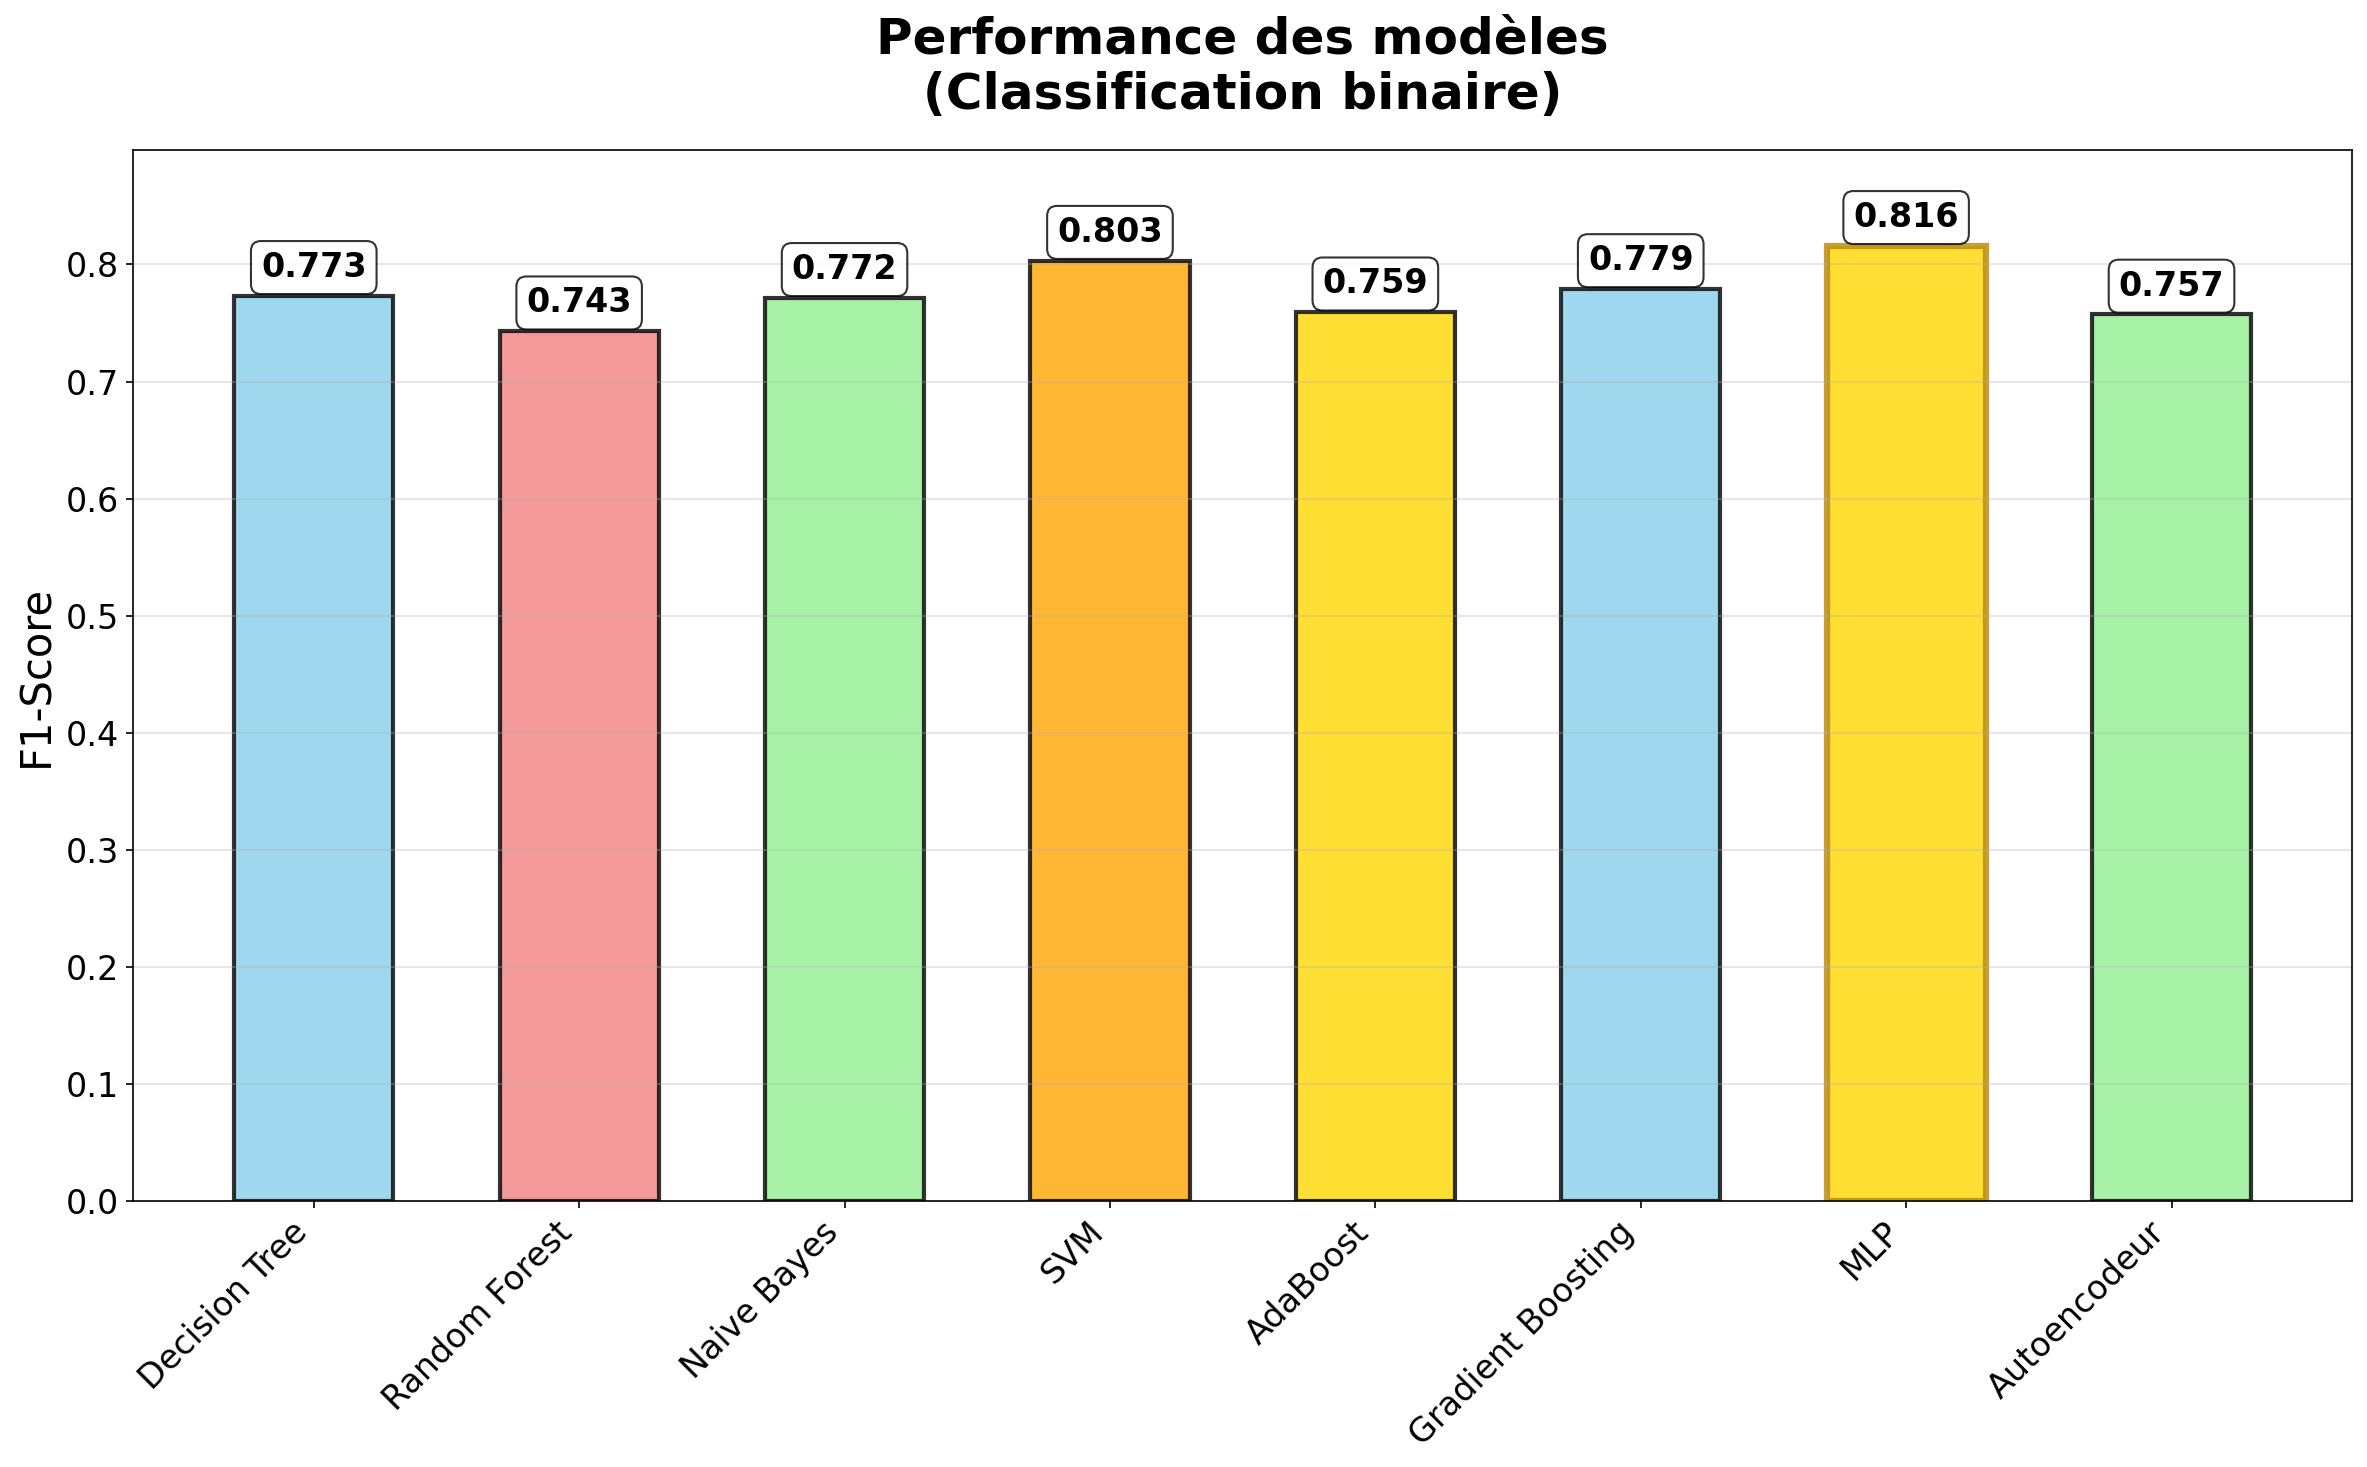

In [122]:
plt.figure(figsize=(16, 10))  # Très grande figure pour un seul graphique

modeles_noms = list(resultats_binaires.keys())
f1_scores = [resultats_binaires[nom]['f1_score'] for nom in modeles_noms]

# Créer le graphique avec des barres plus larges
bars = plt.bar(range(len(modeles_noms)), f1_scores, 
               color=['skyblue', 'lightcoral', 'lightgreen', 'orange', 'gold'], 
               alpha=0.8, width=0.6, edgecolor='black', linewidth=2)

plt.title('Performance des modèles\n(Classification binaire)', 
          fontweight='bold', fontsize=24, pad=20)
plt.ylabel('F1-Score', fontsize=20)
plt.xticks(range(len(modeles_noms)), modeles_noms, 
           rotation=45, ha='right', fontsize=16)
plt.yticks(fontsize=16)
plt.grid(axis='y', alpha=0.3, linewidth=1)

# Mettre en évidence le meilleur modèle
meilleur_idx = f1_scores.index(max(f1_scores))
bars[meilleur_idx].set_color('gold')
bars[meilleur_idx].set_edgecolor('darkgoldenrod')
bars[meilleur_idx].set_linewidth(3)

# Ajouter les valeurs sur chaque barre
for i, (bar, score) in enumerate(zip(bars, f1_scores)):
    plt.text(i, score + 0.01, f'{score:.3f}', 
             ha='center', va='bottom', fontweight='bold', fontsize=16,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.ylim(0, max(f1_scores) * 1.1)
plt.tight_layout()
plt.show()

### GRAPHIQUE 2: IMPACT DE SMOTE

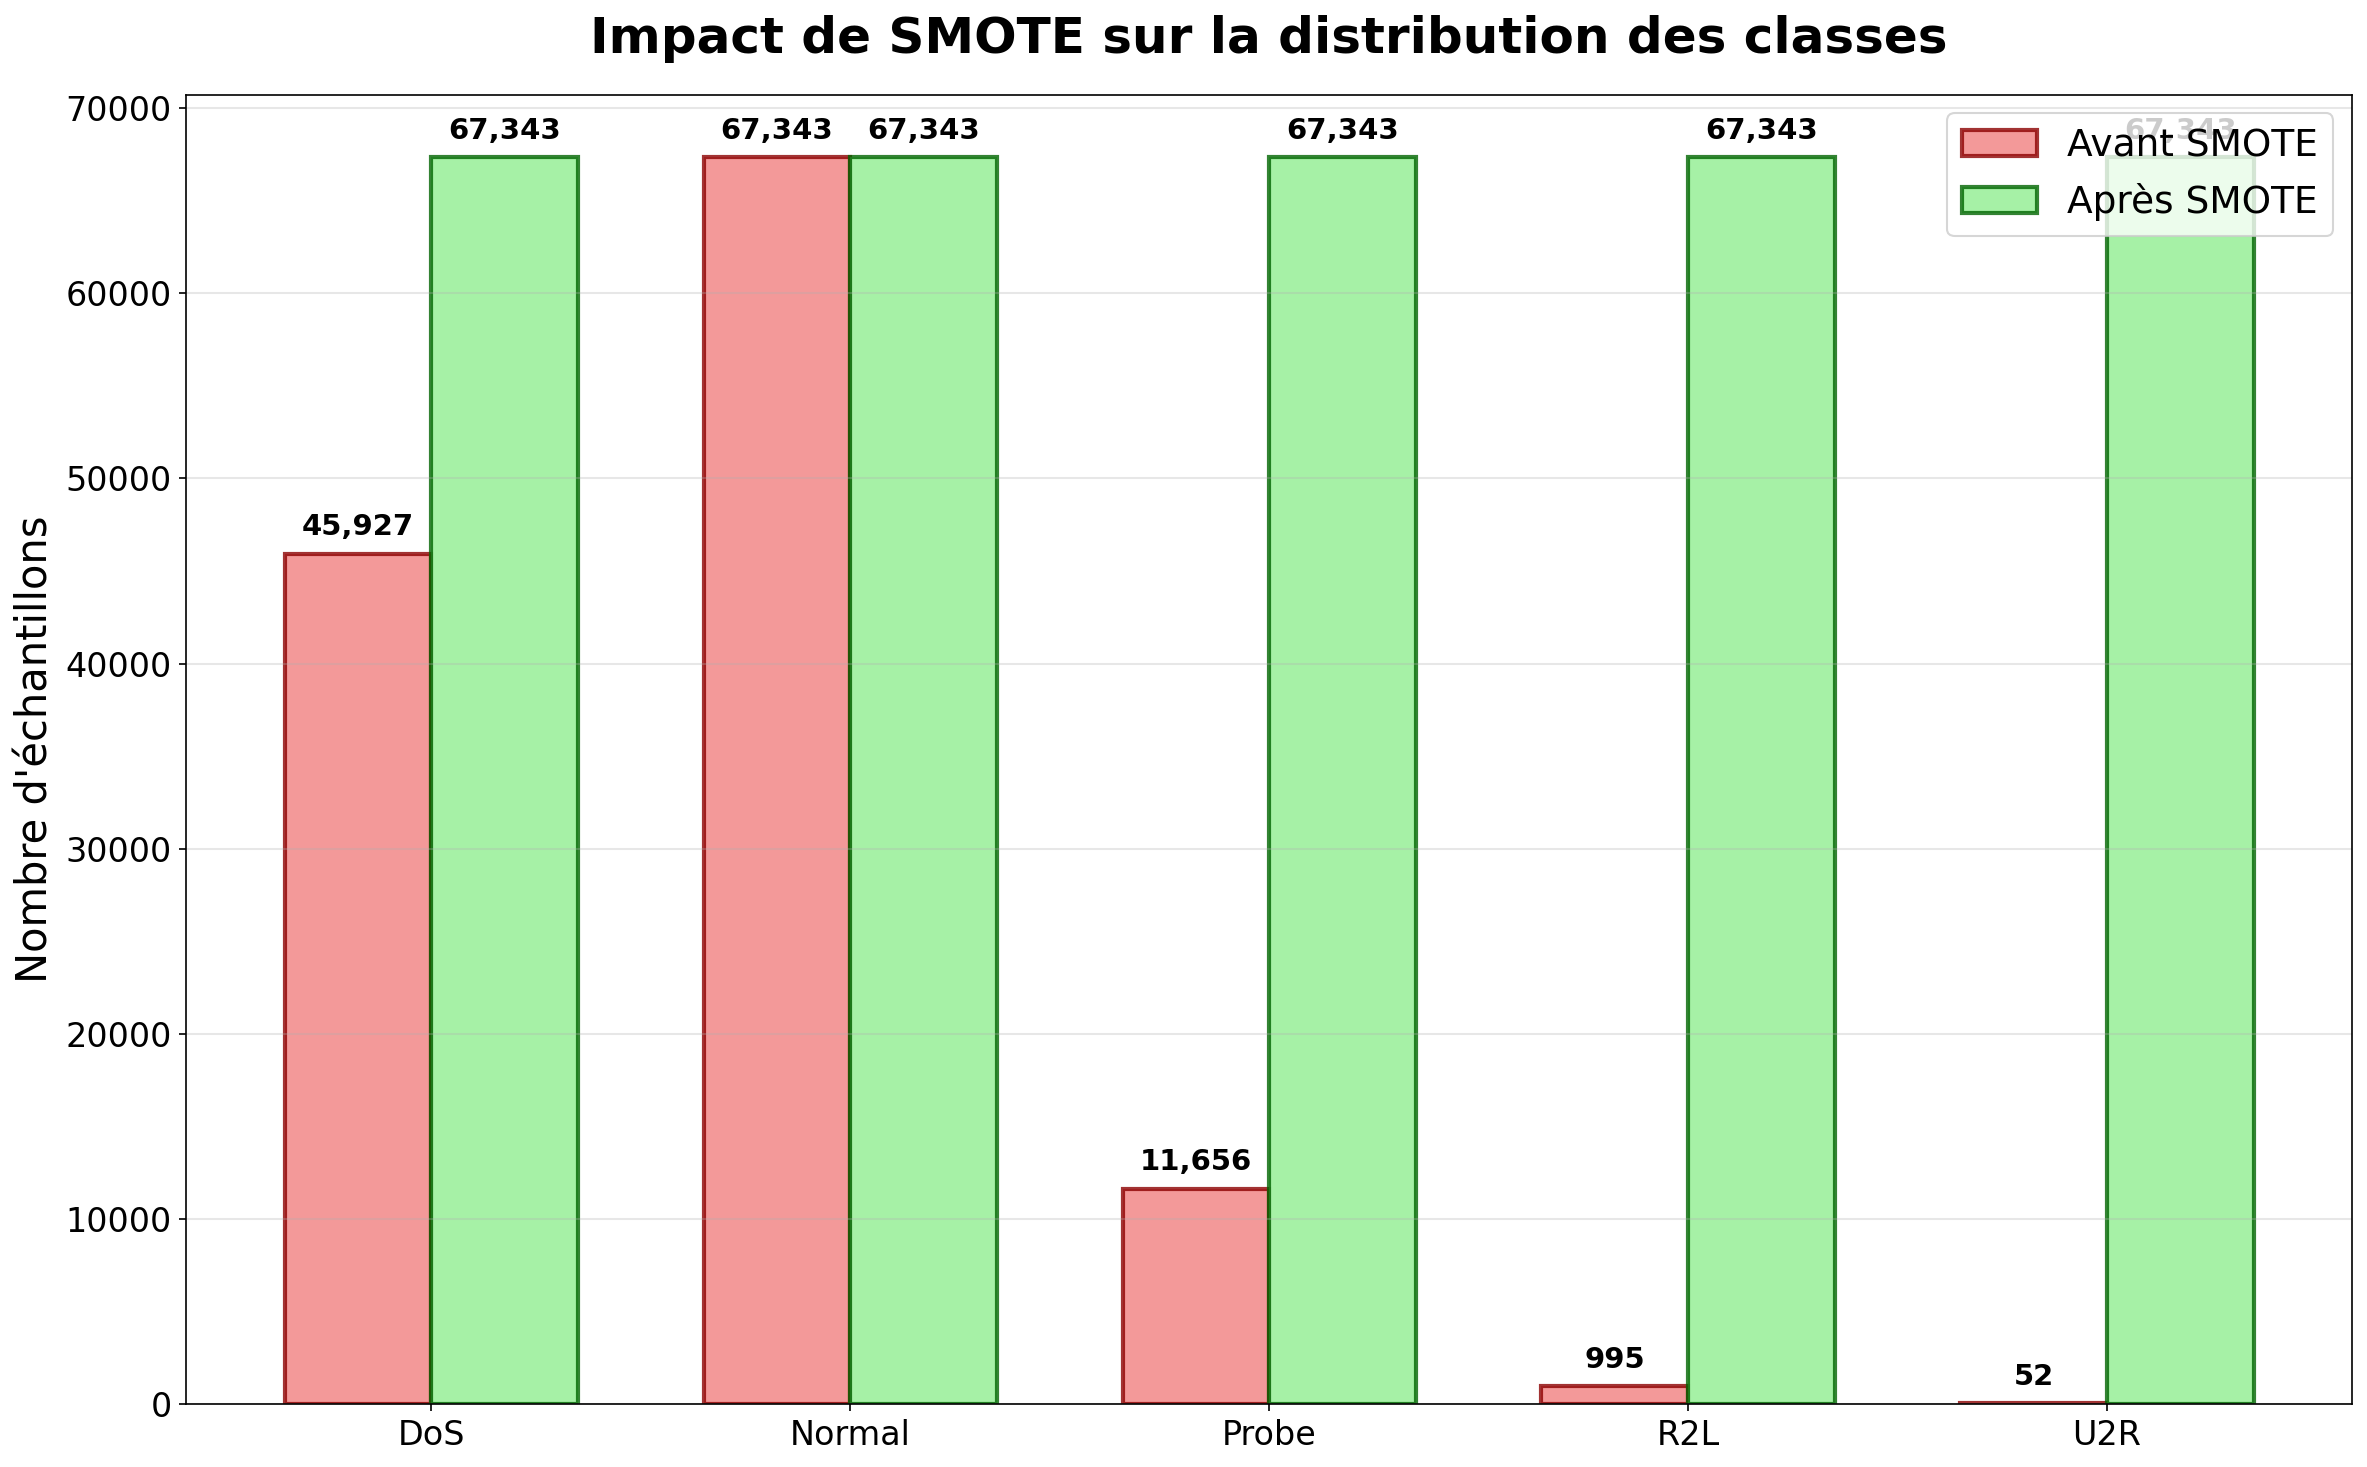

In [123]:
plt.figure(figsize=(16, 10))

# Données pour SMOTE
x_pos = np.arange(len(noms_classes))
width = 0.35

avant_smote = [comptage_classes[i] for i in range(len(noms_classes))]
apres_smote = [comptage_equilibre[i] for i in range(len(noms_classes))]

# Créer les barres
bars1 = plt.bar(x_pos - width/2, avant_smote, width, 
               label='Avant SMOTE', alpha=0.8, color='lightcoral',
               edgecolor='darkred', linewidth=2)
bars2 = plt.bar(x_pos + width/2, apres_smote, width, 
               label='Après SMOTE', alpha=0.8, color='lightgreen',
               edgecolor='darkgreen', linewidth=2)

plt.title('Impact de SMOTE sur la distribution des classes', 
          fontweight='bold', fontsize=24, pad=20)
plt.ylabel('Nombre d\'échantillons', fontsize=20)
plt.xticks(x_pos, noms_classes, fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=18, loc='upper right')
plt.grid(axis='y', alpha=0.3, linewidth=1)

# Ajouter les valeurs sur les barres
for i, (val1, val2) in enumerate(zip(avant_smote, apres_smote)):
    plt.text(i - width/2, val1 + max(avant_smote)*0.01, f'{val1:,}', 
             ha='center', va='bottom', fontweight='bold', fontsize=14)
    plt.text(i + width/2, val2 + max(apres_smote)*0.01, f'{val2:,}', 
             ha='center', va='bottom', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

### GRAPHIQUE 3: PERFORMANCES PAR CLASSE

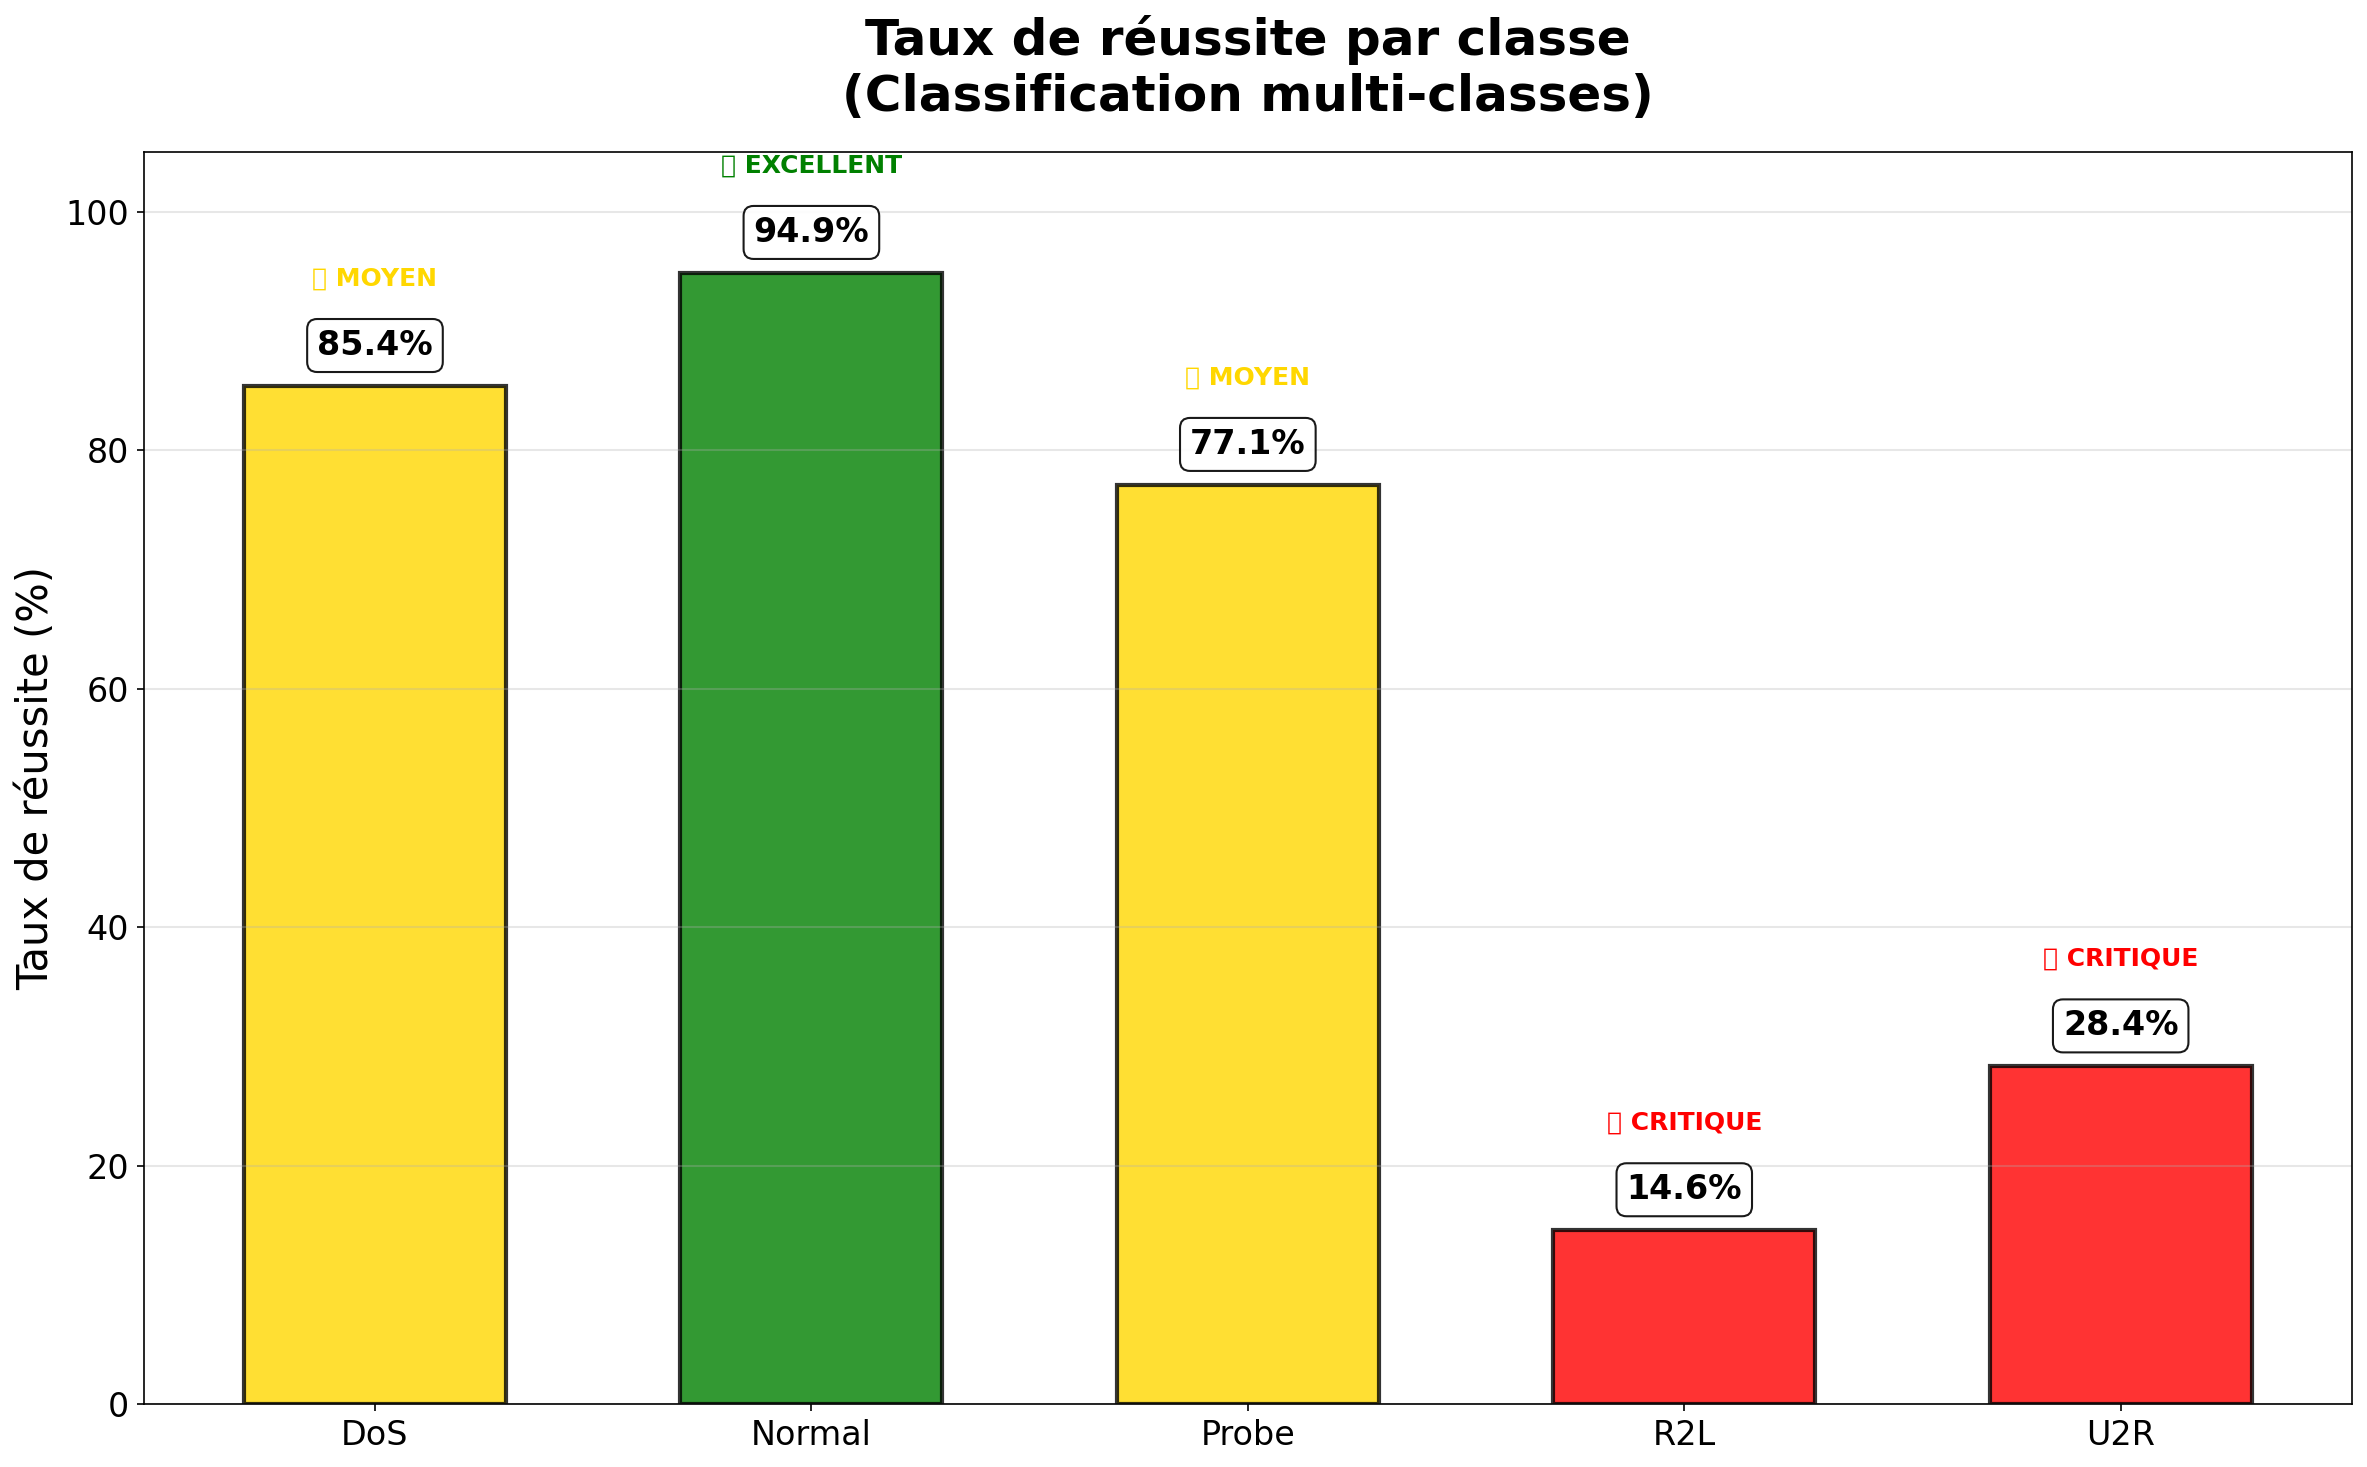

In [124]:
plt.figure(figsize=(16, 10))

classes_performance = [resultats_detailles[classe]['Taux_reussite'] for classe in noms_classes]
couleurs_performance = ['red' if perf < 50 else 'orange' if perf < 70 else 'gold' if perf < 90 else 'green' 
                       for perf in classes_performance]

# Créer le graphique
bars = plt.bar(noms_classes, classes_performance, 
               color=couleurs_performance, alpha=0.8, width=0.6,
               edgecolor='black', linewidth=2)

plt.title('Taux de réussite par classe\n(Classification multi-classes)', 
          fontweight='bold', fontsize=24, pad=20)
plt.ylabel('Taux de réussite (%)', fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.ylim(0, 105)
plt.grid(axis='y', alpha=0.3, linewidth=1)

# Ajouter les valeurs et des annotations colorées
for i, (bar, perf) in enumerate(zip(bars, classes_performance)):
    # Valeur principale
    plt.text(i, perf + 2, f'{perf:.1f}%', ha='center', va='bottom', 
             fontweight='bold', fontsize=16,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.9))
    
    # Annotation de performance
    if perf < 50:
        status = "🔴 CRITIQUE"
        color = "red"
    elif perf < 70:
        status = "🟠 FAIBLE"
        color = "orange"
    elif perf < 90:
        status = "🟡 MOYEN"
        color = "gold"
    else:
        status = "🟢 EXCELLENT"
        color = "green"
    
    plt.text(i, perf + 8, status, ha='center', va='bottom', 
             fontweight='bold', fontsize=12, color=color)

plt.tight_layout()
plt.show()

### GRAPHIQUE 4: MATRICE DE CONFUSION

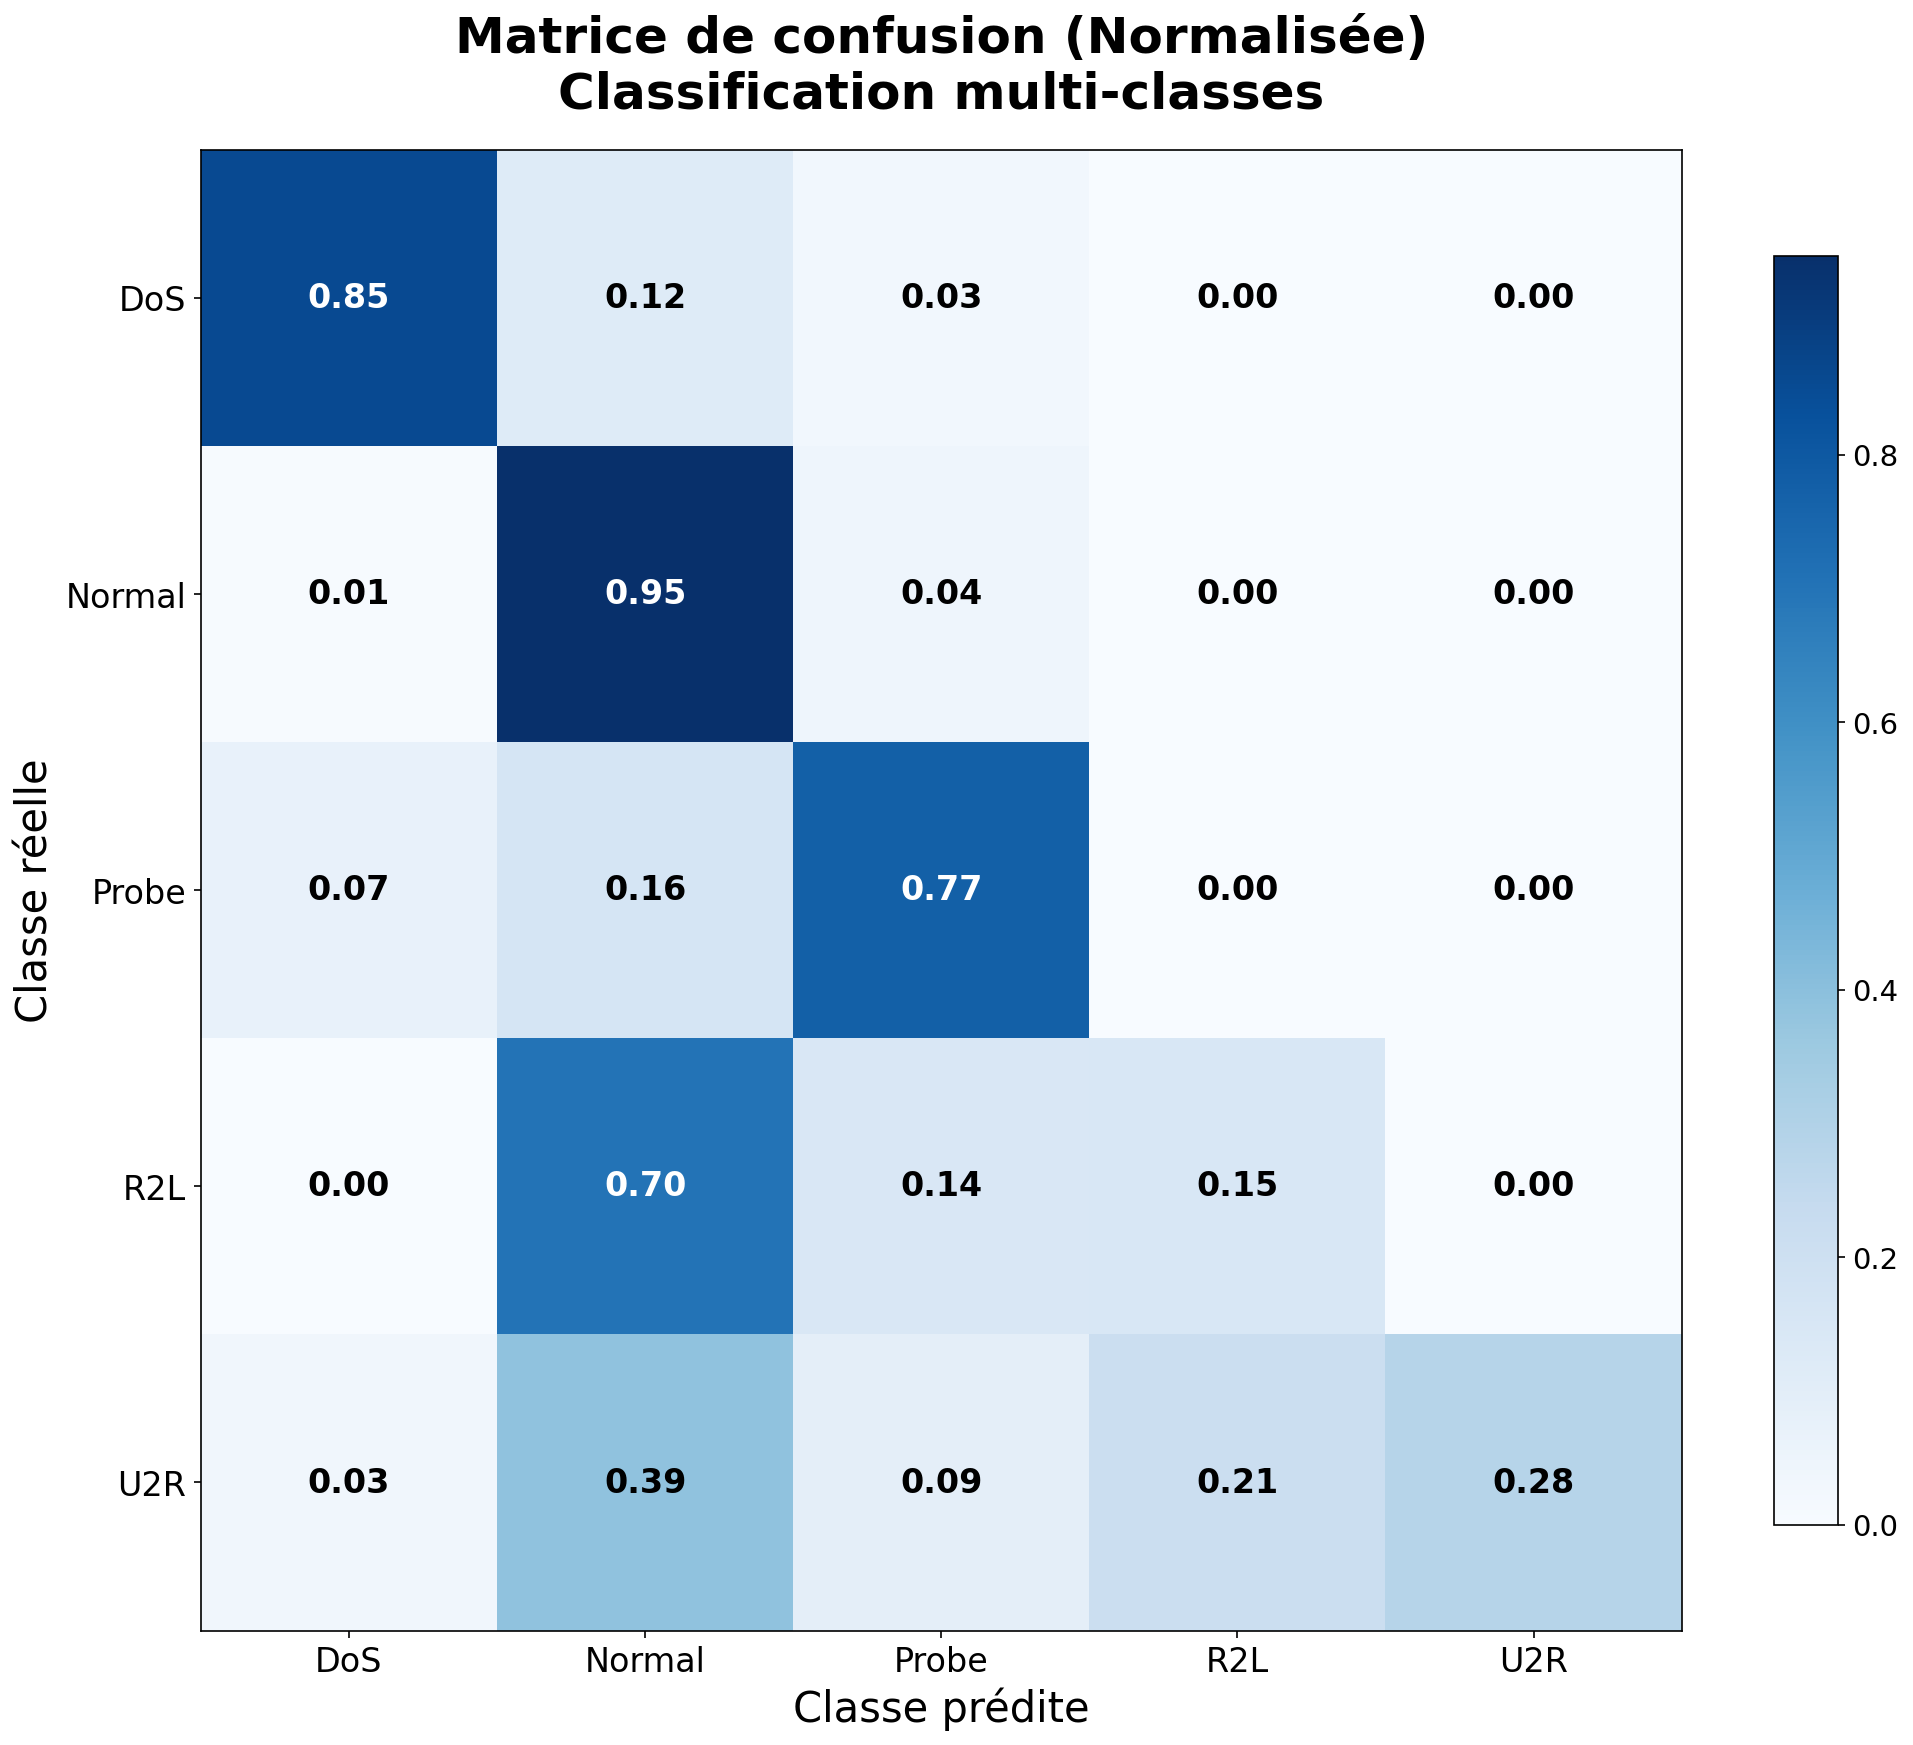

In [125]:
plt.figure(figsize=(14, 12))

matrice_norm = matrice_confusion.astype('float') / matrice_confusion.sum(axis=1)[:, np.newaxis]
im = plt.imshow(matrice_norm, interpolation='nearest', cmap='Blues')

plt.title('Matrice de confusion (Normalisée)\nClassification multi-classes', 
          fontweight='bold', fontsize=24, pad=20)
plt.xticks(range(len(noms_classes)), noms_classes, fontsize=16)
plt.yticks(range(len(noms_classes)), noms_classes, fontsize=16)
plt.xlabel('Classe prédite', fontsize=20)
plt.ylabel('Classe réelle', fontsize=20)

# Colorbar avec taille ajustée
cbar = plt.colorbar(im, shrink=0.8)
cbar.ax.tick_params(labelsize=14)

# Ajouter les valeurs dans les cellules avec des couleurs adaptées
for i in range(len(noms_classes)):
    for j in range(len(noms_classes)):
        text_color = "white" if matrice_norm[i, j] > 0.5 else "black"
        plt.text(j, i, f'{matrice_norm[i, j]:.2f}',
                ha="center", va="center", color=text_color,
                fontweight='bold', fontsize=16)

plt.tight_layout()
plt.show()

### GRAPHIQUE 5: COMPARAISON AVEC/SANS SMOTE

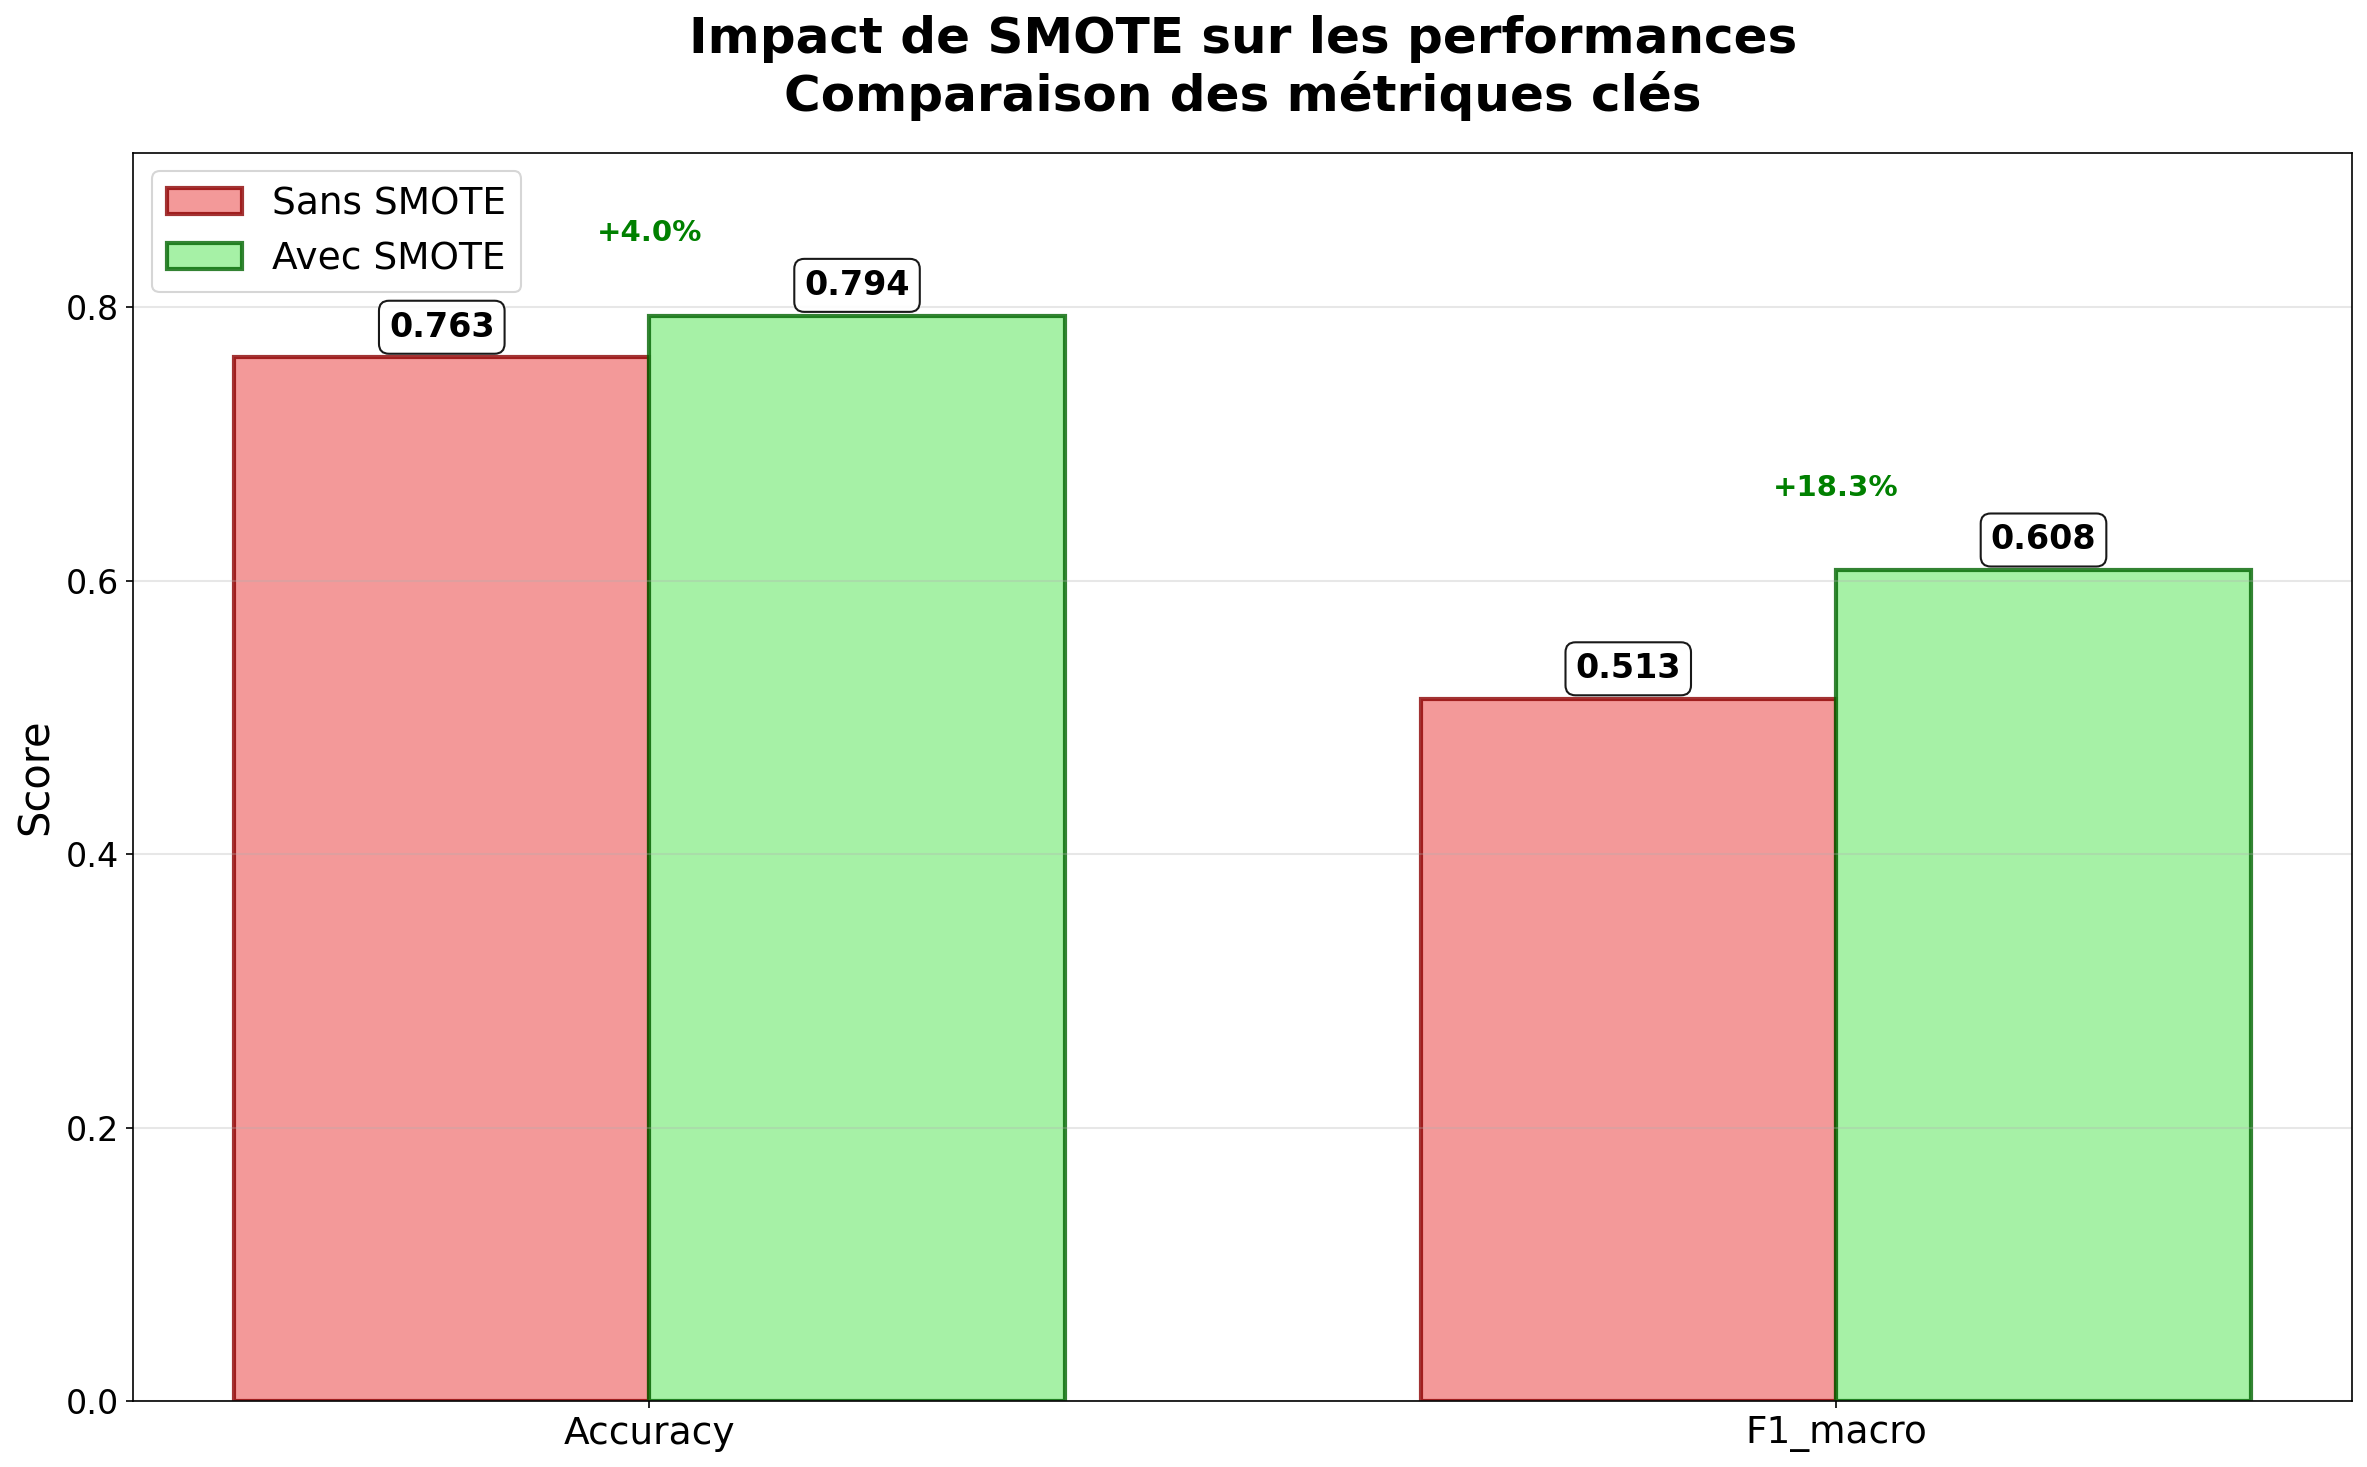

In [126]:
plt.figure(figsize=(16, 10))

metriques_smote = ['Accuracy', 'F1_macro']
sans_smote = [accuracy_sans_smote, f1_macro_sans_smote]
avec_smote = [accuracy_multi, f1_macro]

x_pos_smote = np.arange(len(metriques_smote))
width_smote = 0.35

# Créer les barres avec des couleurs distinctes
bars1 = plt.bar(x_pos_smote - width_smote/2, sans_smote, width_smote, 
               label='Sans SMOTE', alpha=0.8, color='lightcoral',
               edgecolor='darkred', linewidth=2)
bars2 = plt.bar(x_pos_smote + width_smote/2, avec_smote, width_smote, 
               label='Avec SMOTE', alpha=0.8, color='lightgreen',
               edgecolor='darkgreen', linewidth=2)

plt.title('Impact de SMOTE sur les performances\nComparaison des métriques clés', 
          fontweight='bold', fontsize=24, pad=20)
plt.ylabel('Score', fontsize=20)
plt.xticks(x_pos_smote, metriques_smote, fontsize=18)
plt.yticks(fontsize=16)
plt.legend(fontsize=18, loc='upper left')
plt.grid(axis='y', alpha=0.3, linewidth=1)

# Ajouter les valeurs sur les barres
for i, (val1, val2) in enumerate(zip(sans_smote, avec_smote)):
    plt.text(i - width_smote/2, val1 + 0.01, f'{val1:.3f}', 
             ha='center', va='bottom', fontweight='bold', fontsize=16,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.9))
    plt.text(i + width_smote/2, val2 + 0.01, f'{val2:.3f}', 
             ha='center', va='bottom', fontweight='bold', fontsize=16,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.9))
    
    # Calculer et afficher l'amélioration
    amelioration = ((val2 - val1) / val1) * 100
    plt.text(i, max(val1, val2) + 0.05, f'+{amelioration:.1f}%', 
             ha='center', va='bottom', fontweight='bold', fontsize=14,
             color='green' if amelioration > 0 else 'red')

plt.ylim(0, max(max(sans_smote), max(avec_smote)) * 1.15)
plt.tight_layout()
plt.show()

### GRAPHIQUE 6: ENTRAÎNEMENT AUTOENCODEUR

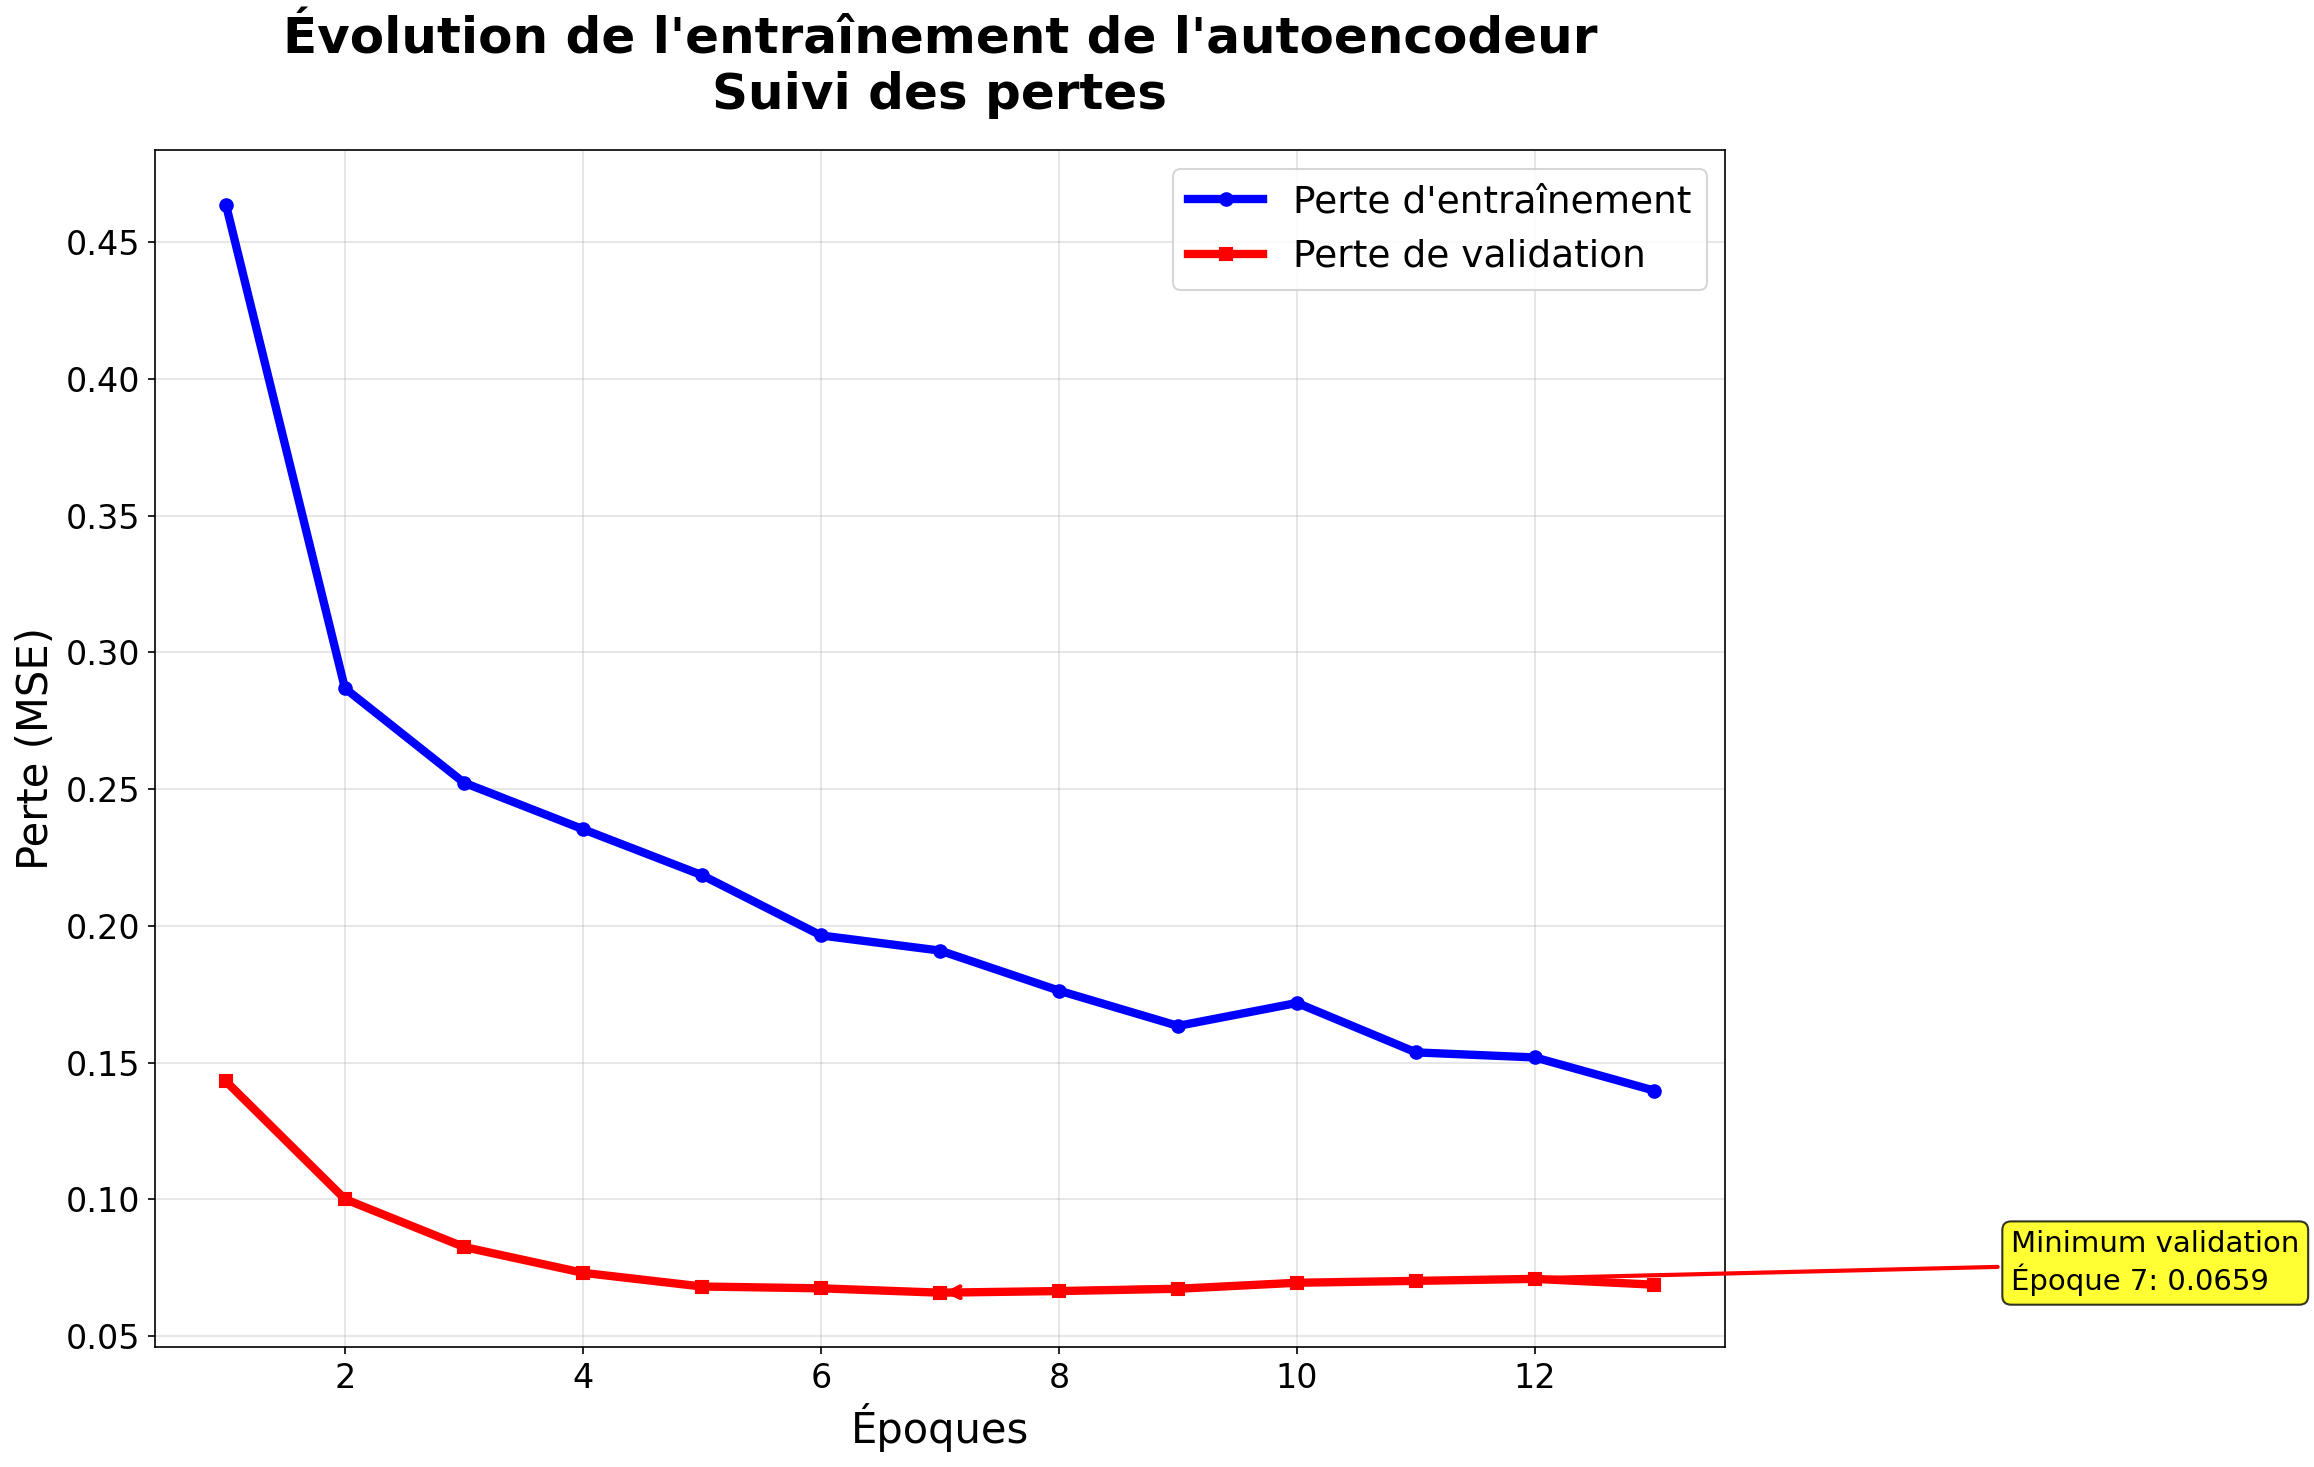

In [127]:
plt.figure(figsize=(16, 10))

epochs = range(1, len(historique.history['loss']) + 1)
plt.plot(epochs, historique.history['loss'], 'b-', 
         label='Perte d\'entraînement', linewidth=4, marker='o', markersize=6)
plt.plot(epochs, historique.history['val_loss'], 'r-', 
         label='Perte de validation', linewidth=4, marker='s', markersize=6)

plt.title('Évolution de l\'entraînement de l\'autoencodeur\nSuivi des pertes', 
          fontweight='bold', fontsize=24, pad=20)
plt.xlabel('Époques', fontsize=20)
plt.ylabel('Perte (MSE)', fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=18, loc='upper right')
plt.grid(alpha=0.3, linewidth=1)

# Ajouter des annotations pour les points clés
min_val_loss_idx = np.argmin(historique.history['val_loss'])
min_val_loss = historique.history['val_loss'][min_val_loss_idx]
plt.annotate(f'Minimum validation\nÉpoque {min_val_loss_idx+1}: {min_val_loss:.4f}',
            xy=(min_val_loss_idx+1, min_val_loss), xytext=(min_val_loss_idx+10, min_val_loss+0.001),
            arrowprops=dict(arrowstyle='->', color='red', lw=2),
            fontsize=14, ha='left',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.8))

plt.tight_layout()
plt.show()

### GRAPHIQUE 7: DISTRIBUTION DES ERREURS

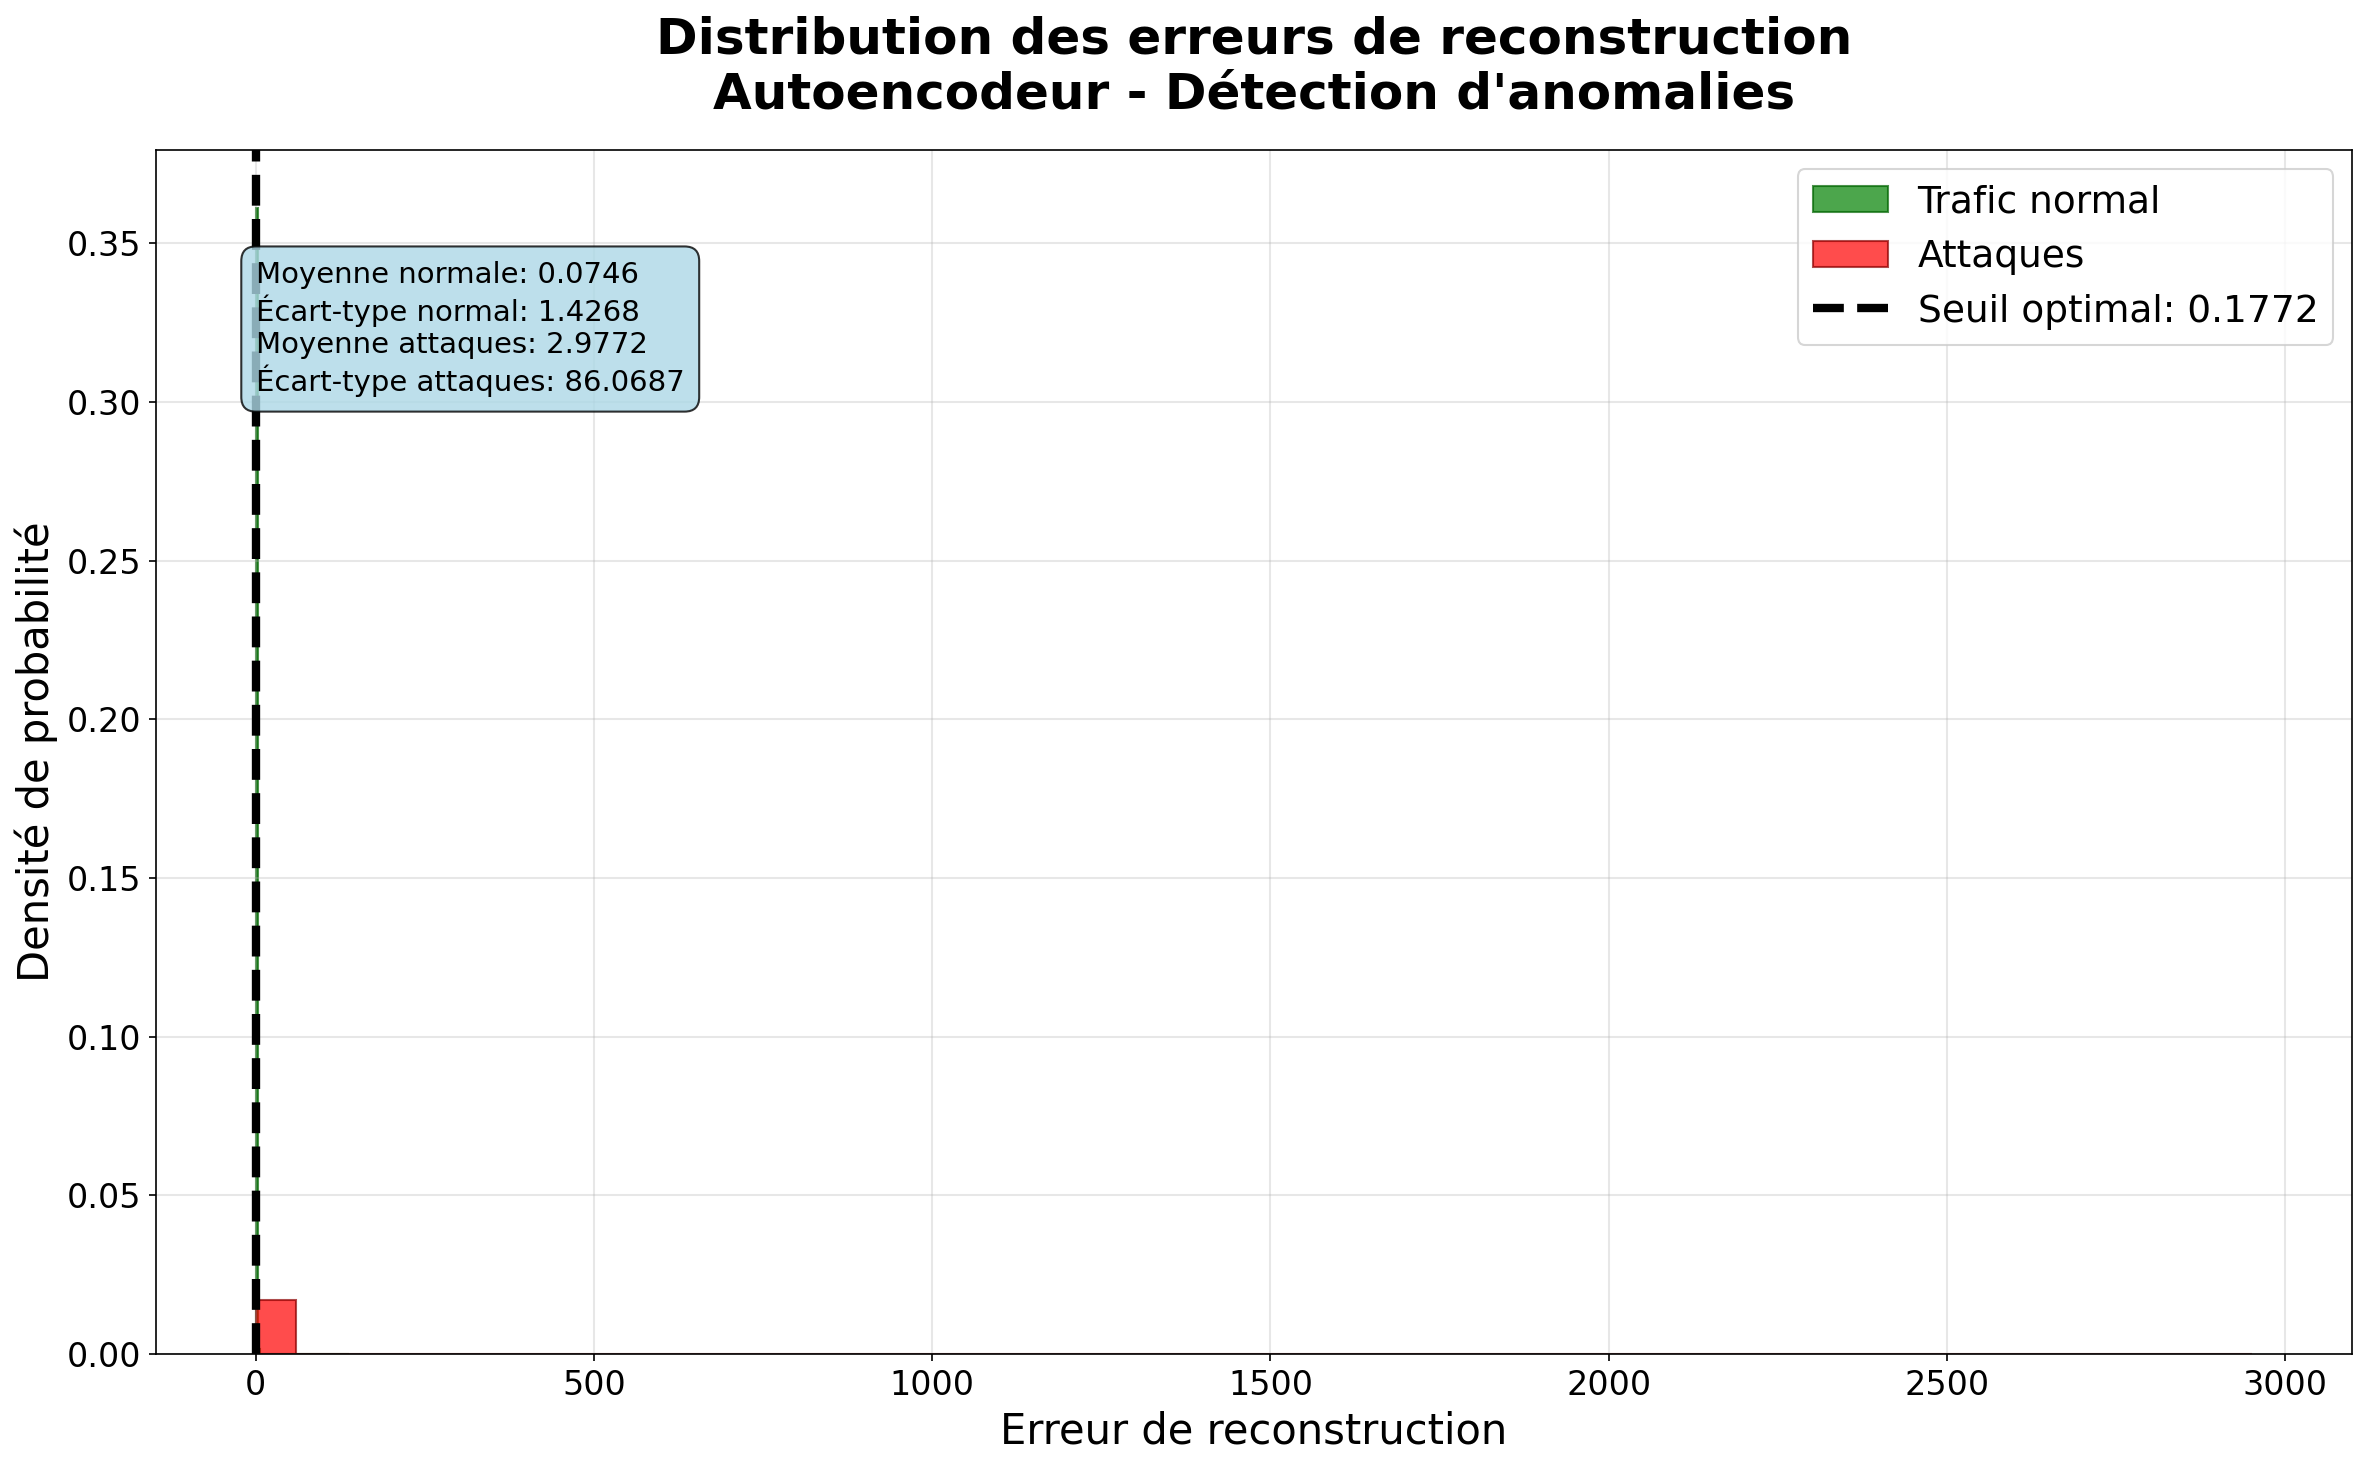

In [128]:
plt.figure(figsize=(16, 10))

erreurs_normales = erreurs_test[y_test_binaire == 0]
erreurs_attaques = erreurs_test[y_test_binaire == 1]

# Créer l'histogramme avec plus de détails
plt.hist(erreurs_normales, bins=50, alpha=0.7, label='Trafic normal', 
         color='green', density=True, edgecolor='darkgreen')
plt.hist(erreurs_attaques, bins=50, alpha=0.7, label='Attaques', 
         color='red', density=True, edgecolor='darkred')
plt.axvline(seuil_anomalie, color='black', linestyle='--', linewidth=4, 
           label=f'Seuil optimal: {seuil_anomalie:.4f}')

plt.title('Distribution des erreurs de reconstruction\nAutoencodeur - Détection d\'anomalies', 
          fontweight='bold', fontsize=24, pad=20)
plt.xlabel('Erreur de reconstruction', fontsize=20)
plt.ylabel('Densité de probabilité', fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=18, loc='upper right')
plt.grid(alpha=0.3, linewidth=1)

# Ajouter des annotations statistiques
plt.text(0.02, plt.ylim()[1]*0.8, 
         f'Moyenne normale: {np.mean(erreurs_normales):.4f}\n'
         f'Écart-type normal: {np.std(erreurs_normales):.4f}\n'
         f'Moyenne attaques: {np.mean(erreurs_attaques):.4f}\n'
         f'Écart-type attaques: {np.std(erreurs_attaques):.4f}',
         fontsize=14, 
         bbox=dict(boxstyle="round,pad=0.5", facecolor="lightblue", alpha=0.8))

plt.tight_layout()
plt.show()


### GRAPHIQUE 8: MÉTRIQUES DÉTAILLÉES

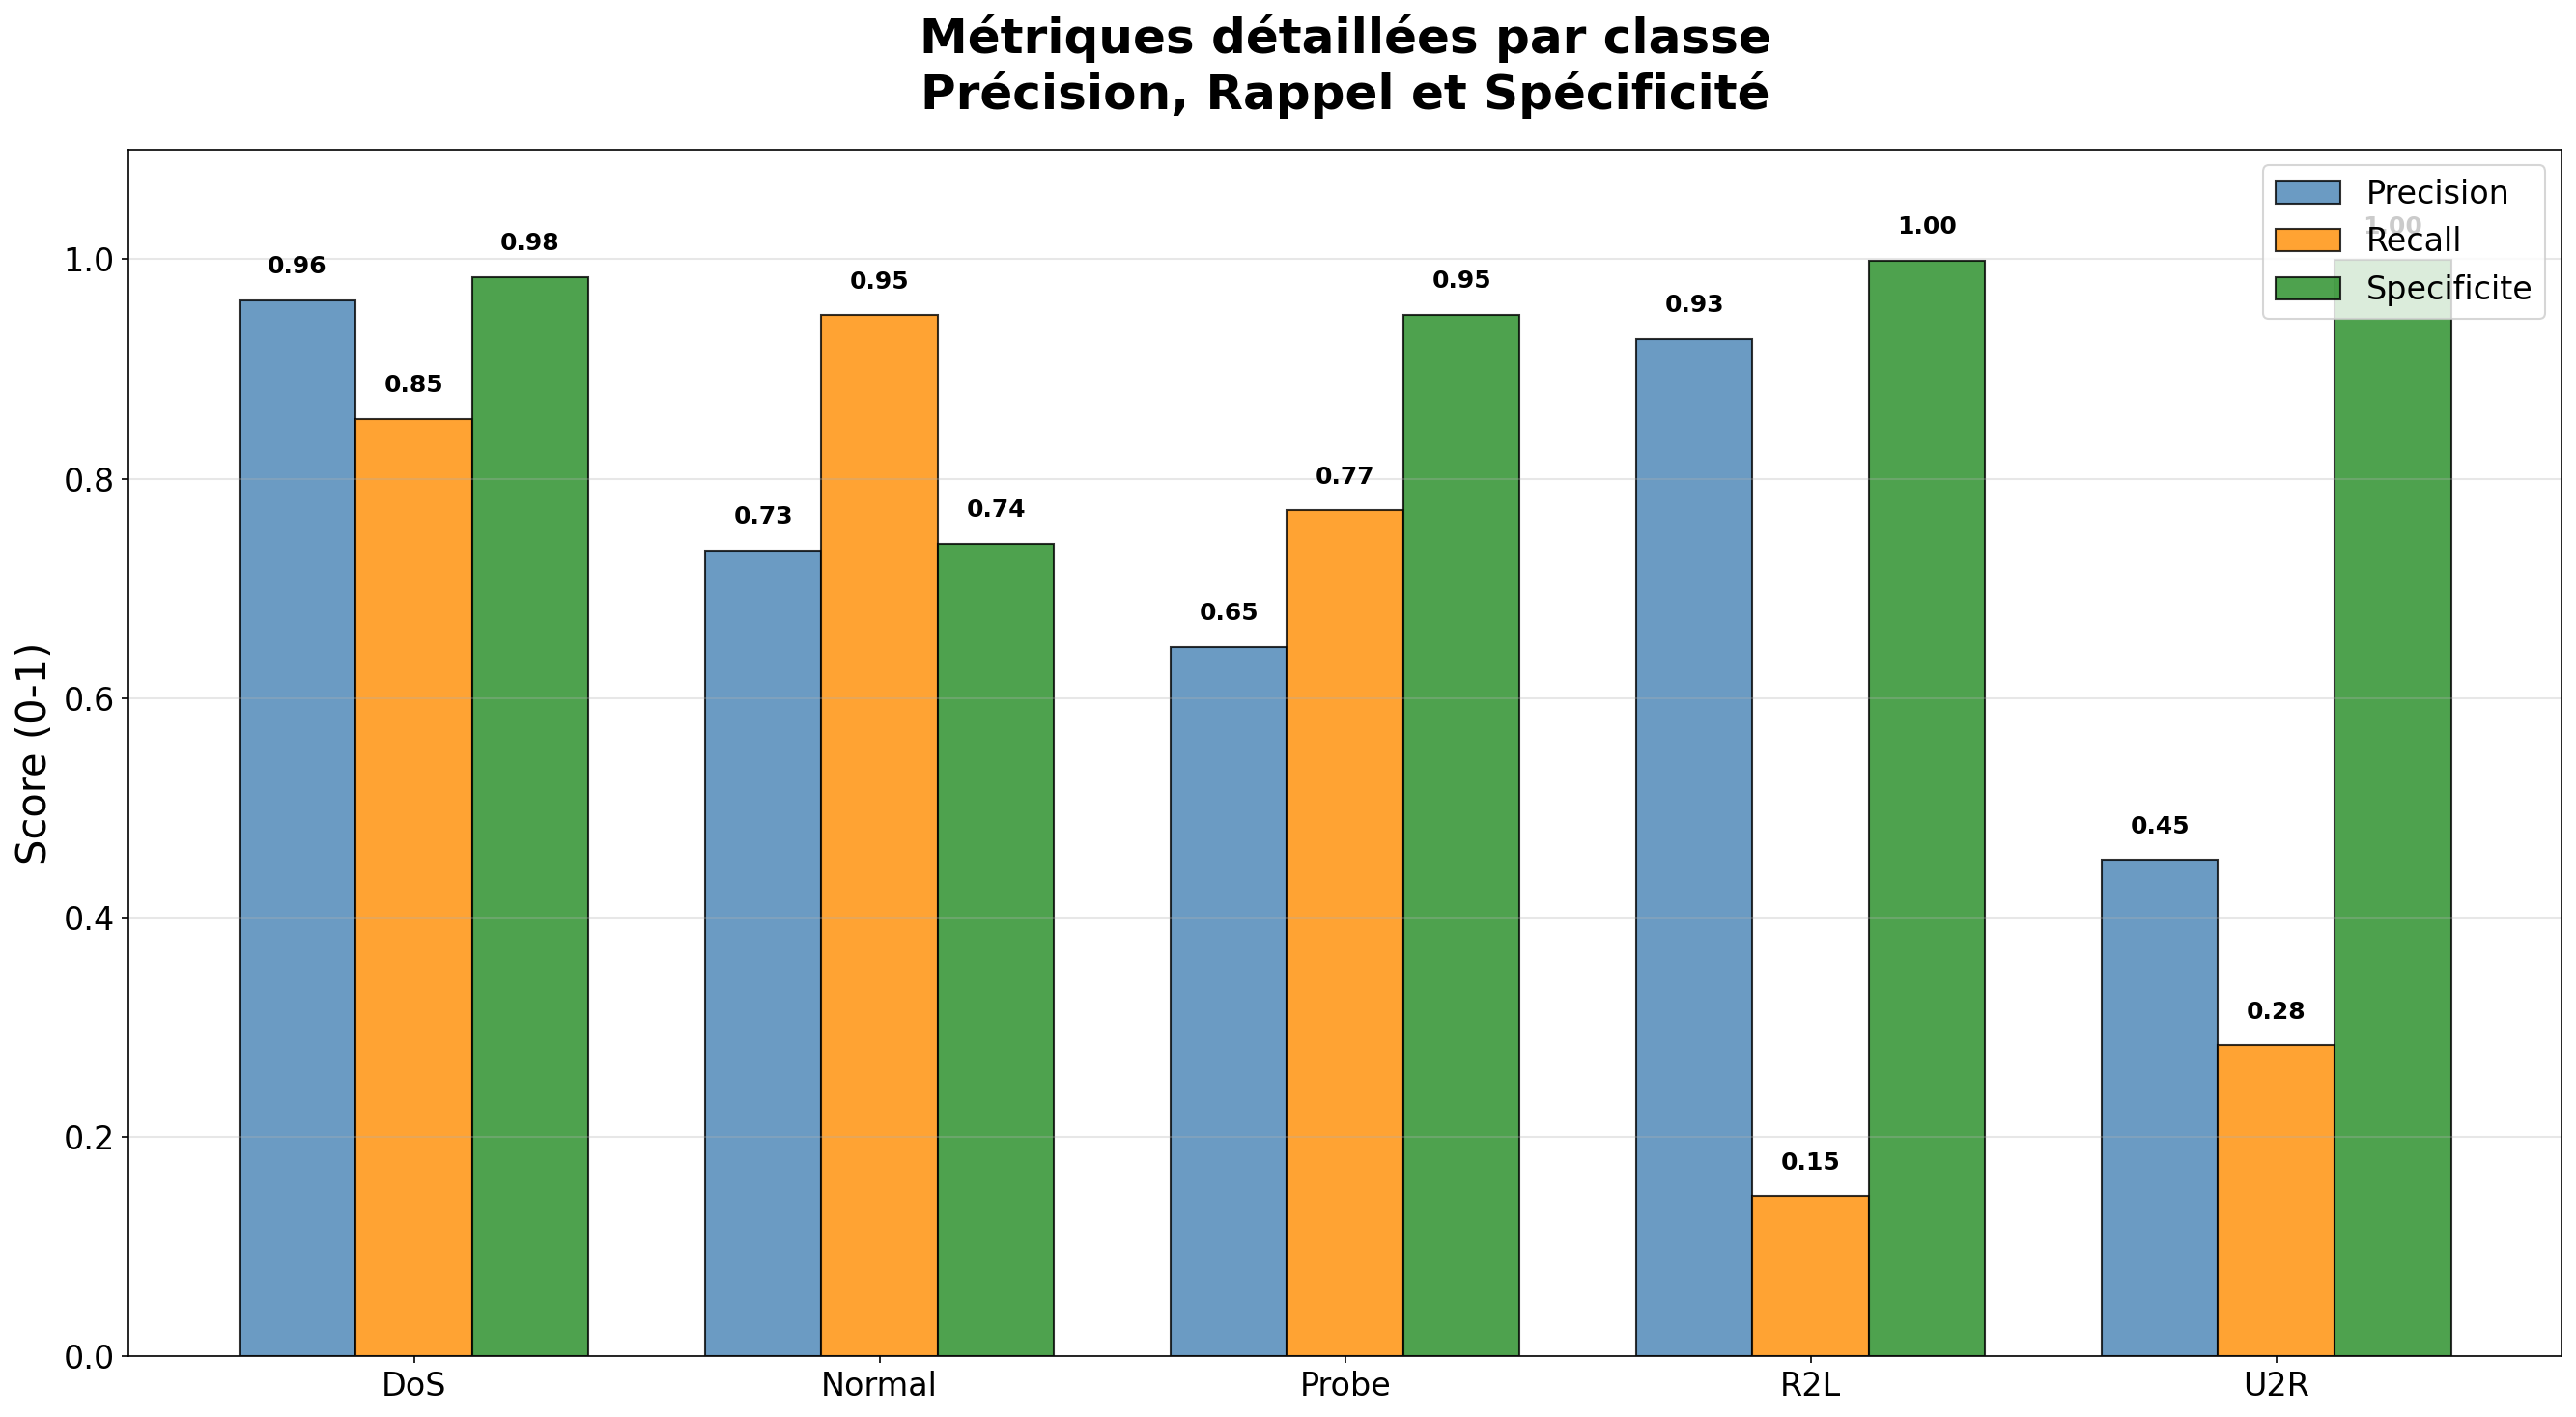

In [129]:
plt.figure(figsize=(18, 10))

metriques = ['Precision', 'Recall', 'Specificite']
x_pos = np.arange(len(noms_classes))
width = 0.25

couleurs = ['steelblue', 'darkorange', 'forestgreen']

for i, metrique in enumerate(metriques):
    valeurs = [resultats_detailles[classe][metrique] for classe in noms_classes]
    bars = plt.bar(x_pos + i*width, valeurs, width, label=metrique, 
                   alpha=0.8, color=couleurs[i], edgecolor='black', linewidth=1)
    
    # Ajouter les valeurs sur les barres
    for j, (bar, val) in enumerate(zip(bars, valeurs)):
        plt.text(j + i*width, val + 0.02, f'{val:.2f}', 
                ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.title('Métriques détaillées par classe\nPrécision, Rappel et Spécificité', 
          fontweight='bold', fontsize=24, pad=20)
plt.ylabel('Score (0-1)', fontsize=20)
plt.xticks(x_pos + width, noms_classes, fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=16, loc='upper right')
plt.grid(axis='y', alpha=0.3, linewidth=1)
plt.ylim(0, 1.1)

plt.tight_layout()
plt.show()